<a href="https://colab.research.google.com/github/DSPL-B17/DSPL_hotelchainA/blob/main/Hotel_Chain_A_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Hotel Booking Cancellation Analysis**

This project analyzes hotel reservation data to identify patterns in booking cancellations and no-shows. The objective is to explore factors influencing reservation outcomes, quantify revenue loss caused by cancellations, and develop a predictive model to estimate cancellation probability.

# **Test, Validation, Train**

## **EDA Preliminary Analysis**

Import Libraries

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Datasets

In [252]:
validation= pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Raw/Hotel-A-validation.csv')
train= pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Raw/Hotel-A-train.csv')
test= pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Raw/Hotel-A-test.csv')

Basic Dataset Overview

In [253]:
# Check dataset dimensions (rows, columns)
validation.shape

(2749, 24)

In [254]:
train.shape

(27499, 24)

In [255]:
test.shape

(4318, 23)

Preview the Data

In [256]:
# Display first few rows of the dataset
validation.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,45716350,M,56,caucasian,Grad,<25K,West,Resort,8/31/2016,9/2/2016,...,HB,No,No,No Deposit,Agent,No,No-Show,Yes,15,192
1,88857401,M,60,Latino,College,25K --50K,West,Resort,8/31/2016,9/4/2016,...,FB,Yes,No,No Deposit,Online,Yes,Canceled,No,0,187
2,16074440,F,58,Asian American,College,<25K,North,Airport Hotels,9/1/2016,9/2/2016,...,FB,No,No,No Deposit,Direct,No,Canceled,Yes,10,227
3,10992124,F,23,Latino,College,25K --50K,East,Airport Hotels,8/31/2016,9/2/2016,...,FB,Yes,No,Refundable,Direct,No,Check-In,Yes,25,189
4,15934351,F,47,Asian American,College,25K --50K,South,City Hotel,8/31/2016,9/1/2016,...,HB,Yes,No,No Deposit,Online,Yes,Check-In,Yes,10,218


In [257]:
train.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,7/1/2015,7/2/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes,10,218
1,77491756,F,49,Latino,Mid-School,50K -- 100K,East,City Hotel,7/1/2015,7/2/2015,...,BB,No,No,Refundable,Online,Yes,Check-Out,No,0,185
2,73747291,F,42,caucasian,Grad,<25K,East,City Hotel,7/2/2015,7/6/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,119
3,67301739,M,25,African American,College,>100K,South,Airport Hotels,7/2/2015,7/3/2015,...,BB,No,No,Refundable,Agent,Yes,Check-Out,Yes,5,144
4,77222321,F,62,Latino,High-School,25K --50K,East,Resort,7/3/2015,7/4/2015,...,BB,No,No,No Deposit,Direct,No,Check-Out,Yes,10,242


In [134]:
test.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Babies,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Use_Promotion,Discount_Rate,Room_Rate
0,62931593,F,52,Latino,Grad,25K --50K,South,City Hotel,11/18/2016,11/19/2016,...,0,HB,No,No,No Deposit,Direct,Yes,Yes,10,153
1,70586099,F,47,Latino,Grad,25K --50K,East,Airport Hotels,11/18/2016,11/19/2016,...,0,FB,No,No,No Deposit,Online,No,No,0,210
2,4230648,F,28,Asian American,Grad,<25K,East,City Hotel,4/28/2017,5/1/2017,...,0,BB,No,No,No Deposit,Agent,No,Yes,5,117
3,25192322,F,65,caucasian,High-School,25K --50K,South,Airport Hotels,11/18/2016,11/20/2016,...,2,FB,No,No,No Deposit,Online,Yes,Yes,10,107
4,80931528,M,45,African American,College,25K --50K,South,City Hotel,11/18/2016,11/20/2016,...,0,BB,No,No,Refundable,Agent,No,No,0,119


Data Types

In [258]:
# Display column names, data types, and non-null counts
validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2749 entries, 0 to 2748
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          2749 non-null   int64 
 1   Gender                  2749 non-null   object
 2   Age                     2749 non-null   int64 
 3   Ethnicity               2749 non-null   object
 4   Educational_Level       2749 non-null   object
 5   Income                  2749 non-null   object
 6   Country_region          2749 non-null   object
 7   Hotel_Type              2749 non-null   object
 8   Expected_checkin        2749 non-null   object
 9   Expected_checkout       2749 non-null   object
 10  Booking_date            2749 non-null   object
 11  Adults                  2749 non-null   int64 
 12  Children                2749 non-null   int64 
 13  Babies                  2749 non-null   int64 
 14  Meal_Type               2749 non-null   object
 15  Vist

In [259]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27499 entries, 0 to 27498
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          27499 non-null  int64 
 1   Gender                  27499 non-null  object
 2   Age                     27499 non-null  int64 
 3   Ethnicity               27499 non-null  object
 4   Educational_Level       27499 non-null  object
 5   Income                  27499 non-null  object
 6   Country_region          27499 non-null  object
 7   Hotel_Type              27499 non-null  object
 8   Expected_checkin        27499 non-null  object
 9   Expected_checkout       27499 non-null  object
 10  Booking_date            27499 non-null  object
 11  Adults                  27499 non-null  int64 
 12  Children                27499 non-null  int64 
 13  Babies                  27499 non-null  int64 
 14  Meal_Type               27499 non-null  object
 15  Vi

In [260]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4318 entries, 0 to 4317
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          4318 non-null   int64 
 1   Gender                  4318 non-null   object
 2   Age                     4318 non-null   int64 
 3   Ethnicity               4318 non-null   object
 4   Educational_Level       4318 non-null   object
 5   Income                  4318 non-null   object
 6   Country_region          4318 non-null   object
 7   Hotel_Type              4318 non-null   object
 8   Expected_checkin        4318 non-null   object
 9   Expected_checkout       4318 non-null   object
 10  Booking_date            4318 non-null   object
 11  Adults                  4318 non-null   int64 
 12  Children                4318 non-null   int64 
 13  Babies                  4318 non-null   int64 
 14  Meal_Type               4318 non-null   object
 15  Vist

Summary Statistics

Numerical Variables Summary

In [261]:
validation.describe().T

,count,mean,std,min,25%,50%,75%,max
Reservation-id,2749.0,4.991827e+07,2.888011e+07,143.0,24843132.0,49328761.0,74712969.0,99988487.0
Age,2749.0,4.419680e+01,1.521221e+01,18.0,31.0,44.0,57.0,70.0
Adults,2749.0,2.336850e+00,1.185808e+00,1.0,1.0,2.0,3.0,5.0
Children,2749.0,1.740633e+00,7.249131e-01,1.0,1.0,2.0,2.0,3.0
Babies,2749.0,3.339396e-01,5.669973e-01,0.0,0.0,0.0,1.0,2.0
Discount_Rate,2749.0,1.248454e+01,1.116618e+01,0.0,5.0,10.0,20.0,40.0
Room_Rate,2749.0,1.737425e+02,4.388018e+01,100.0,136.0,173.0,212.0,250.0


In [262]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Reservation-id,27499.0,5.016461e+07,2.886911e+07,3154.0,25239432.0,50149955.0,75182883.0,99999005.0
Age,27499.0,4.397745e+01,1.530315e+01,18.0,31.0,44.0,57.0,70.0
Adults,27499.0,2.333576e+00,1.176526e+00,1.0,2.0,2.0,3.0,5.0
Children,27499.0,1.743882e+00,7.219721e-01,1.0,1.0,2.0,2.0,3.0
Babies,27499.0,3.515401e-01,5.733259e-01,0.0,0.0,0.0,1.0,2.0
Discount_Rate,27499.0,1.249518e+01,1.120604e+01,0.0,5.0,10.0,20.0,40.0
Room_Rate,27499.0,1.751365e+02,4.387709e+01,100.0,137.0,175.0,214.0,250.0


In [264]:
test.describe().T

,count,mean,std,min,25%,50%,75%,max
Reservation-id,4318.0,5.042908e+07,2.879425e+07,68318.0,25476853.0,51123488.0,75158645.0,99983667.0
Age,4318.0,4.378833e+01,1.525708e+01,18.0,31.0,44.0,57.0,70.0
Adults,4318.0,2.369847e+00,1.191075e+00,1.0,2.0,2.0,3.0,5.0
Children,4318.0,1.730199e+00,7.214061e-01,1.0,1.0,2.0,2.0,3.0
Babies,4318.0,3.457619e-01,5.663683e-01,0.0,0.0,0.0,1.0,2.0
Discount_Rate,4318.0,1.241663e+01,1.126684e+01,0.0,5.0,10.0,20.0,40.0
Room_Rate,4318.0,1.755720e+02,4.294178e+01,100.0,139.0,176.0,212.0,250.0


Categorical Variables Summary

In [265]:
categorical_columns = train.select_dtypes(include='object').columns
categorical_columns

Index(['Gender', 'Ethnicity', 'Educational_Level', 'Income', 'Country_region',
       'Hotel_Type', 'Expected_checkin', 'Expected_checkout', 'Booking_date',
       'Meal_Type', 'Visted_Previously', 'Previous_Cancellations',
       'Deposit_type', 'Booking_channel', 'Required_Car_Parking',
       'Reservation_Status', 'Use_Promotion'],
      dtype='object')

In [266]:
def categorical_summary(df):
    # Dynamically get categorical columns for the current DataFrame
    df_categorical_columns = df.select_dtypes(include='object').columns

    summary = pd.DataFrame({
        'Unique_Values': df[df_categorical_columns].nunique(),
        'Most_Frequent': df[df_categorical_columns].mode().iloc[0],
        'Frequency': df[df_categorical_columns].apply(lambda x: x.value_counts().iloc[0])
    })

    return summary

In [267]:
validation_cat_summary = categorical_summary(validation)
validation_cat_summary

,Unique_Values,Most_Frequent,Frequency
Gender,2,F,1396
Ethnicity,4,caucasian,697
Educational_Level,4,College,1124
Income,4,50K -- 100K,786
Country_region,4,South,1093
Hotel_Type,3,Airport Hotels,976
Expected_checkin,151,10/6/2016,86
Expected_checkout,156,10/13/2016,67
Booking_date,322,6/1/2016,23
Meal_Type,3,FB,937


In [268]:
train_cat_summary = categorical_summary(train)
train_cat_summary

,Unique_Values,Most_Frequent,Frequency
Gender,2,F,13799
Ethnicity,4,African American,6965
Educational_Level,4,College,11052
Income,4,50K -- 100K,7936
Country_region,4,South,10917
Hotel_Type,3,Airport Hotels,9258
Expected_checkin,901,2/9/2016,145
Expected_checkout,929,2/10/2016,91
Booking_date,1133,10/19/2015,232
Meal_Type,3,BB,14224


In [269]:
test_cat_summary = categorical_summary(test)
test_cat_summary

,Unique_Values,Most_Frequent,Frequency
Gender,2,F,2169
Ethnicity,4,Asian American,1114
Educational_Level,4,College,1705
Income,4,25K --50K,1244
Country_region,4,South,1722
Hotel_Type,3,Airport Hotels,1466
Expected_checkin,191,1/19/2017,107
Expected_checkout,194,1/20/2017,67
Booking_date,370,10/29/2016,28
Meal_Type,3,FB,1461


## **EDA (Before Cleaning)**

An initial exploratory data analysis (EDA) was conducted on the raw dataset to understand its structure, identify missing values, detect inconsistencies, and observe general patterns.

### Univariate Analysis

Reservation Status Distribution

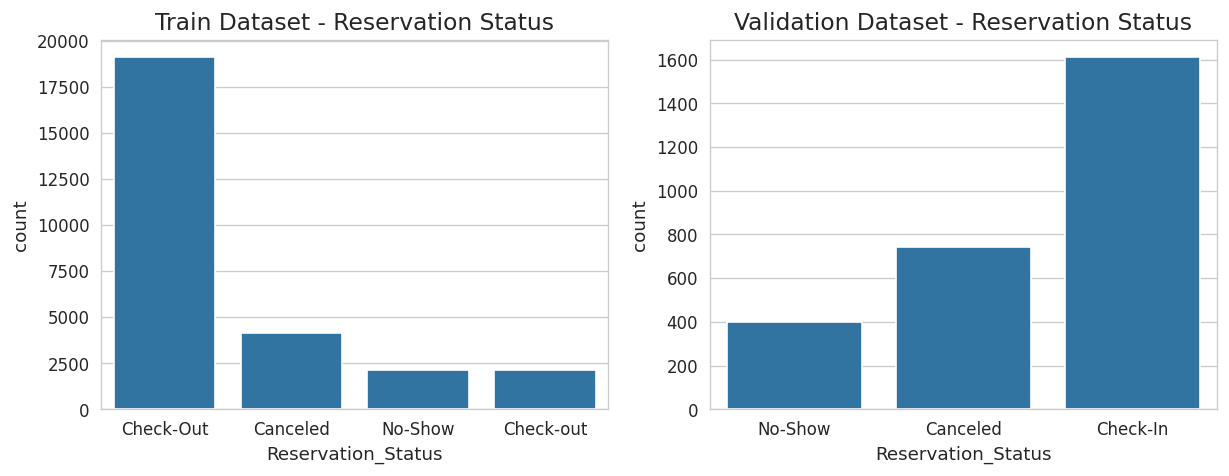

In [270]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x='Reservation_Status', data=train)
plt.title("Train Dataset - Reservation Status")

plt.subplot(1,2,2)
sns.countplot(x='Reservation_Status', data=validation)
plt.title("Validation Dataset - Reservation Status")

plt.show()

Hotel Type Distribution

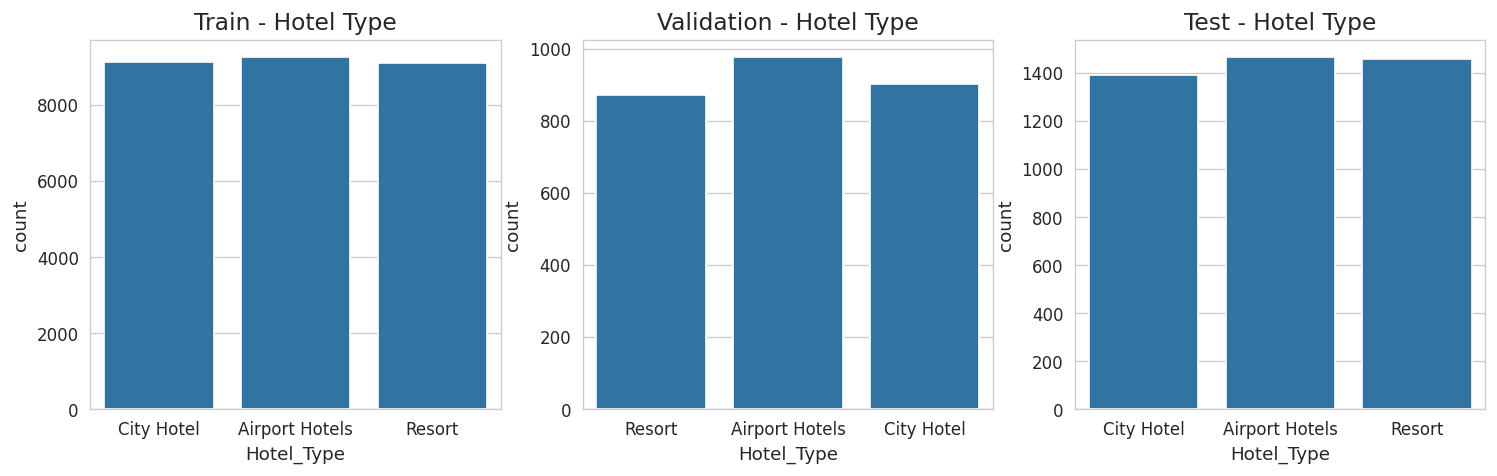

In [271]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.countplot(x='Hotel_Type', data=train)
plt.title("Train - Hotel Type")

plt.subplot(1,3,2)
sns.countplot(x='Hotel_Type', data=validation)
plt.title("Validation - Hotel Type")

plt.subplot(1,3,3)
sns.countplot(x='Hotel_Type', data=test)
plt.title("Test - Hotel Type")

plt.show()

Booking Channel Distribution

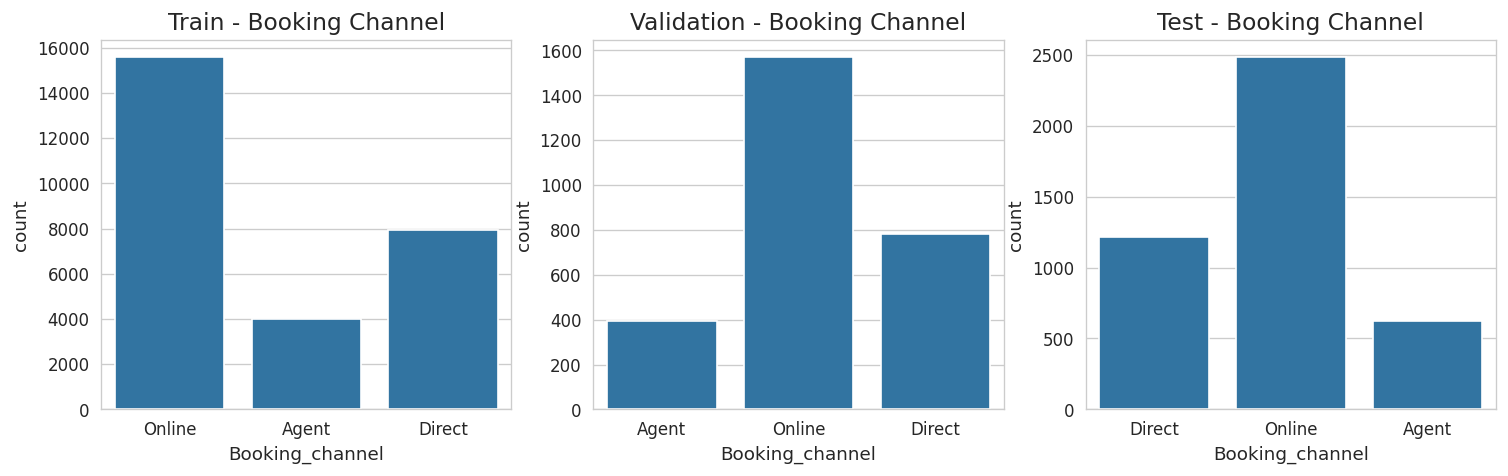

In [272]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.countplot(x='Booking_channel', data=train)
plt.title("Train - Booking Channel")

plt.subplot(1,3,2)
sns.countplot(x='Booking_channel', data=validation)
plt.title("Validation - Booking Channel")

plt.subplot(1,3,3)
sns.countplot(x='Booking_channel', data=test)
plt.title("Test - Booking Channel")

plt.show()

Room Rate Distribution

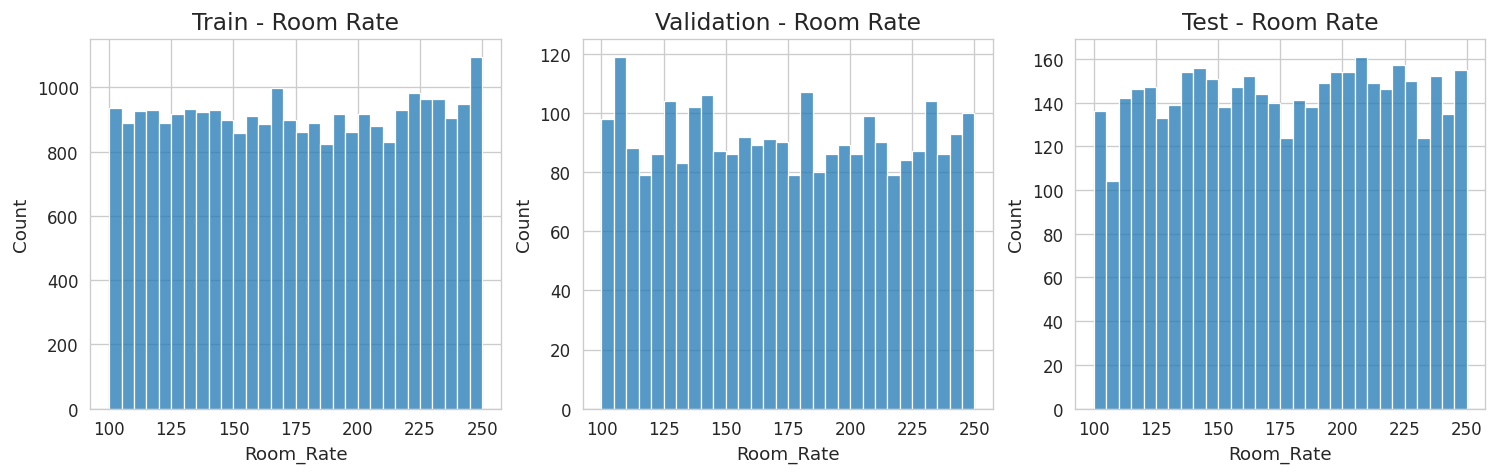

In [273]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(train['Room_Rate'], bins=30)
plt.title("Train - Room Rate")

plt.subplot(1,3,2)
sns.histplot(validation['Room_Rate'], bins=30)
plt.title("Validation - Room Rate")

plt.subplot(1,3,3)
sns.histplot(test['Room_Rate'], bins=30)
plt.title("Test - Room Rate")

plt.show()

### Bivariate Analysis

Hotel Type vs Reservation Status

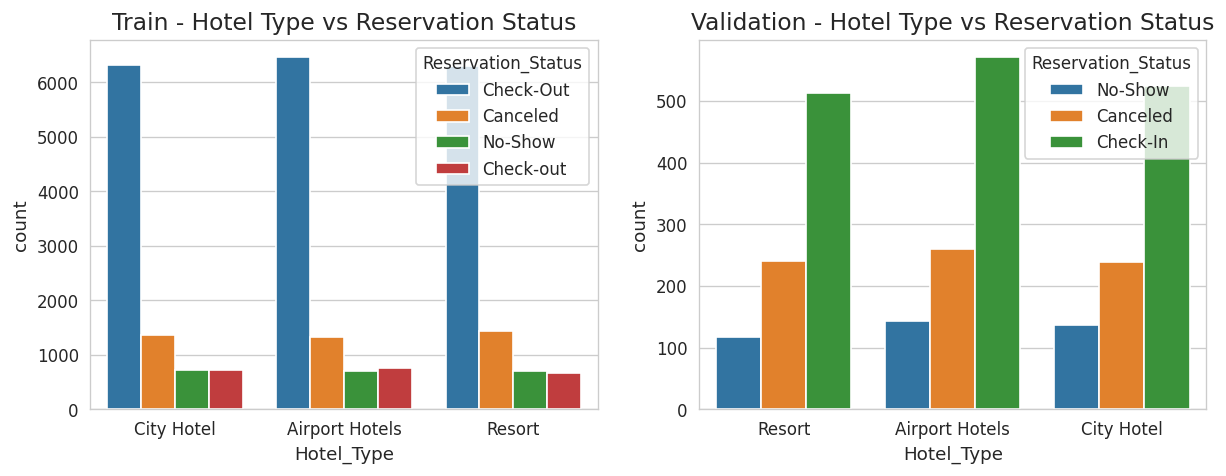

In [274]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x='Hotel_Type', hue='Reservation_Status', data=train)
plt.title("Train - Hotel Type vs Reservation Status")

plt.subplot(1,2,2)
sns.countplot(x='Hotel_Type', hue='Reservation_Status', data=validation)
plt.title("Validation - Hotel Type vs Reservation Status")

plt.show()

Booking Channel vs Reservation Status

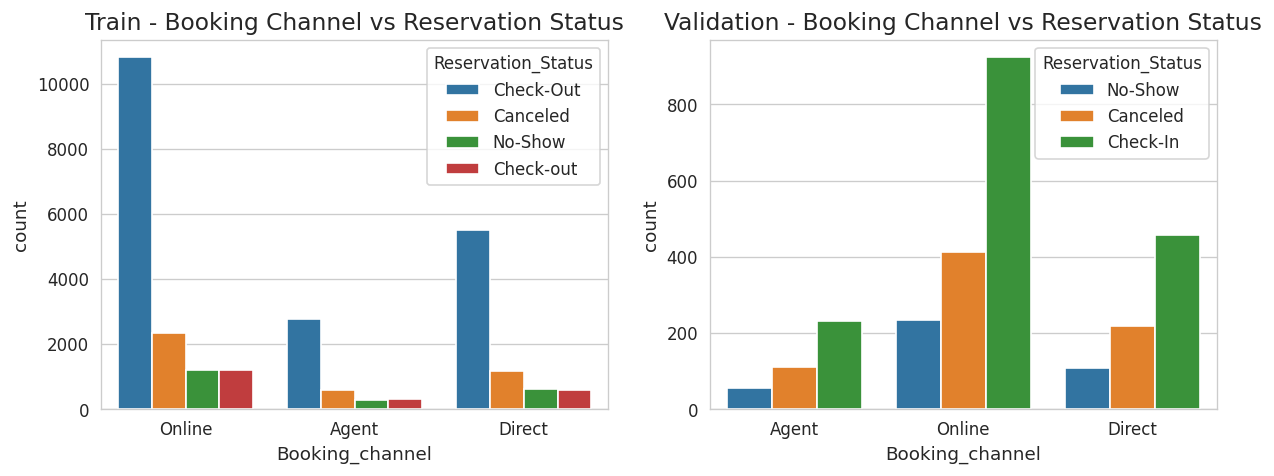

In [275]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x='Booking_channel', hue='Reservation_Status', data=train)
plt.title("Train - Booking Channel vs Reservation Status")

plt.subplot(1,2,2)
sns.countplot(x='Booking_channel', hue='Reservation_Status', data=validation)
plt.title("Validation - Booking Channel vs Reservation Status")

plt.show()

Room Rate vs Reservation Status

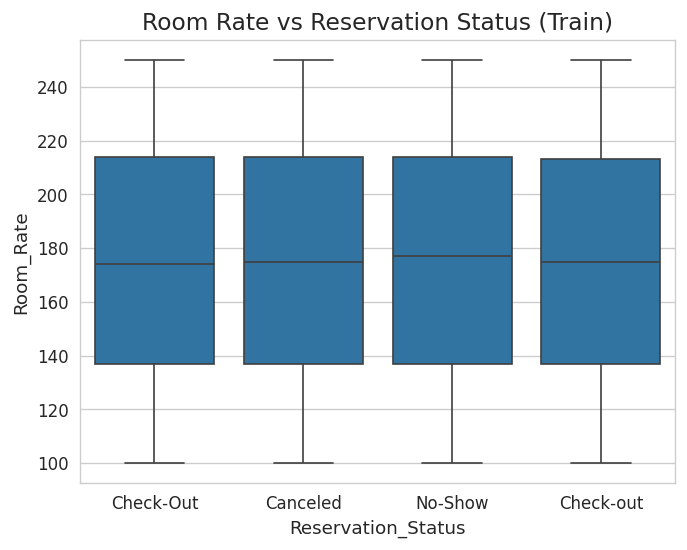

In [276]:
sns.boxplot(x='Reservation_Status', y='Room_Rate', data=train)
plt.title("Room Rate vs Reservation Status (Train)")
plt.show()

### Multivariate Analysis

#### Cluster Analysis

Hotel Type vs Booking Channel vs Reservation Status

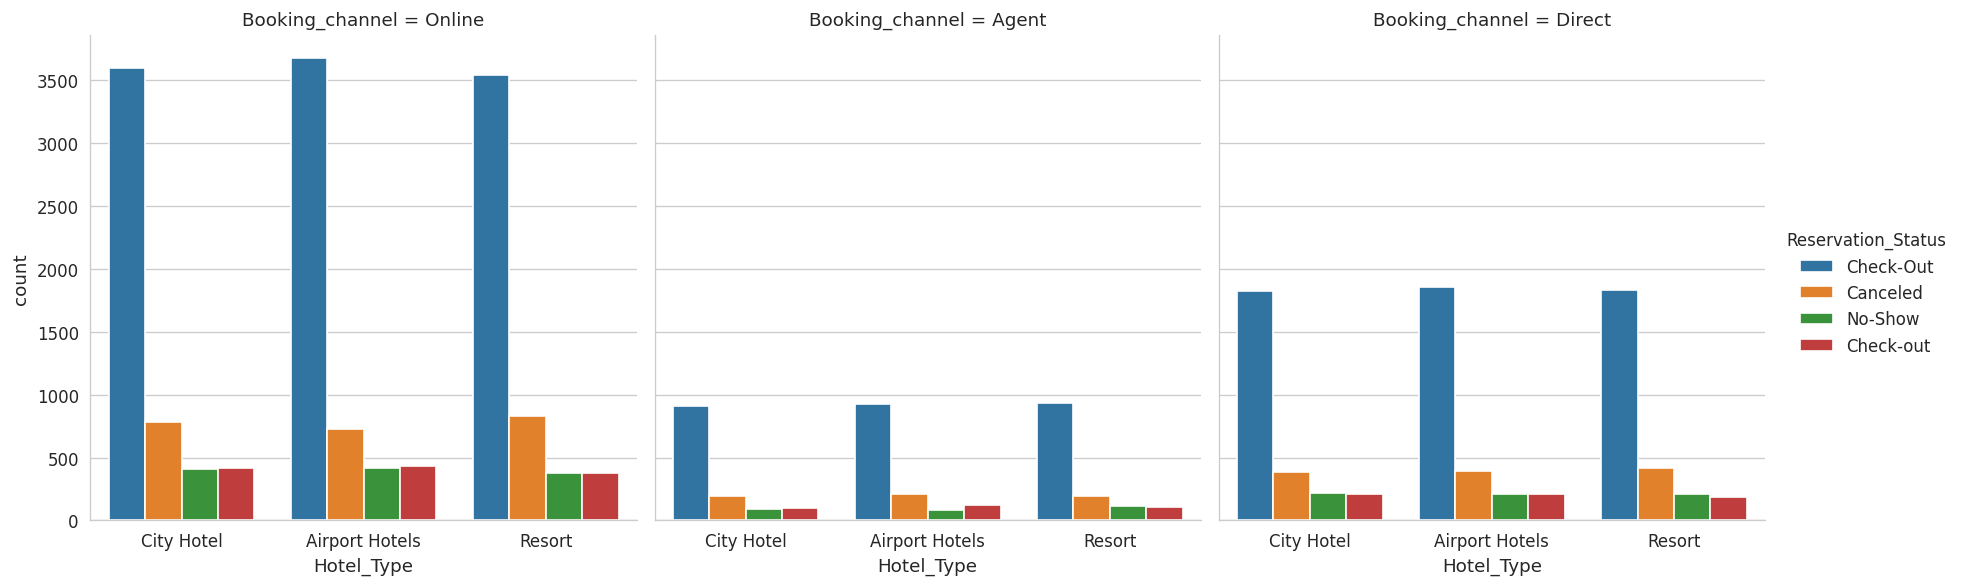

In [277]:
sns.catplot(
    x='Hotel_Type',
    hue='Reservation_Status',
    col='Booking_channel',
    kind='count',
    data=train
)

plt.show()

Correlation Matrix

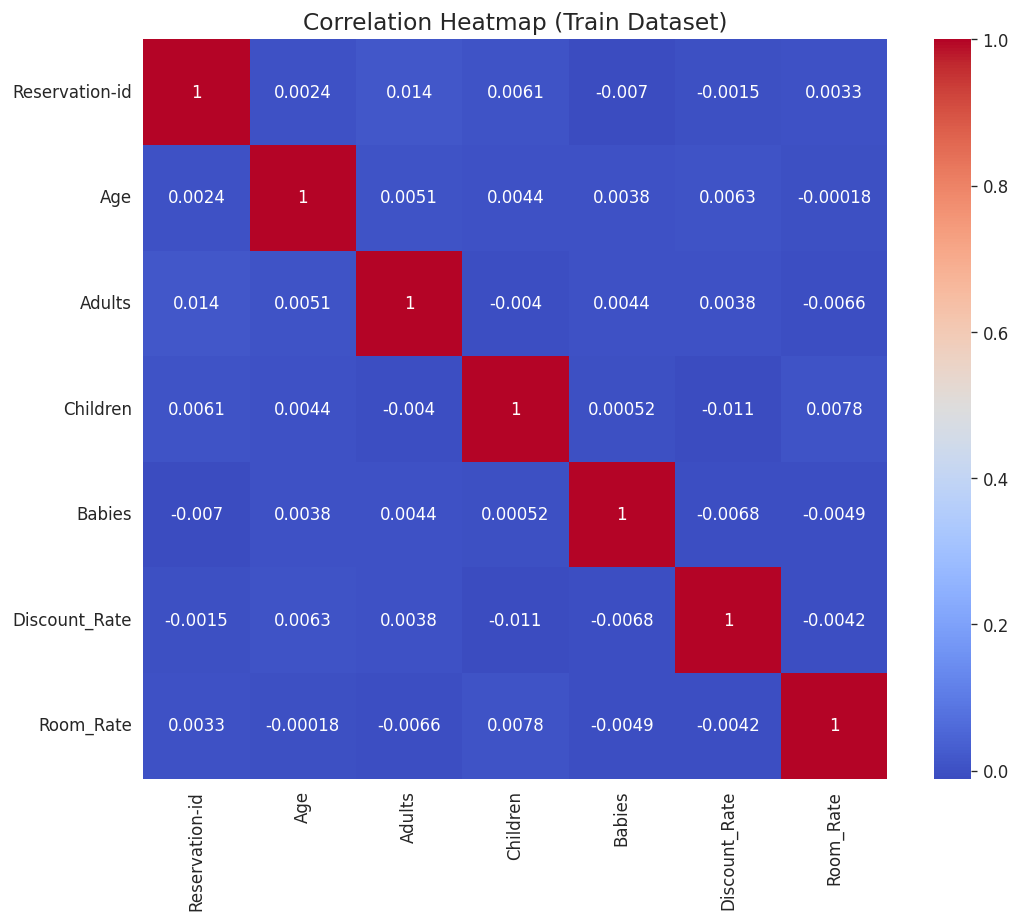

In [278]:
plt.figure(figsize=(10,8))

numeric_cols = train.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap (Train Dataset)")
plt.show()

## **Data Cleaning**

Check missing values

In [279]:
validation.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [280]:
missing_summary = pd.DataFrame({
    'Missing Values': validation.isnull().sum(),
    'Percentage (%)': (validation.isnull().sum() / len(validation)) * 100
})

missing_summary

,Missing Values,Percentage (%)
Reservation-id,0,0.0
Gender,0,0.0
Age,0,0.0
Ethnicity,0,0.0
Educational_Level,0,0.0
Income,0,0.0
Country_region,0,0.0
Hotel_Type,0,0.0
Expected_checkin,0,0.0
Expected_checkout,0,0.0


In [281]:
train.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [282]:
missing_summary = pd.DataFrame({
    'Missing Values': train.isnull().sum(),
    'Percentage (%)': (train.isnull().sum() / len(train)) * 100
})

missing_summary

,Missing Values,Percentage (%)
Reservation-id,0,0.0
Gender,0,0.0
Age,0,0.0
Ethnicity,0,0.0
Educational_Level,0,0.0
Income,0,0.0
Country_region,0,0.0
Hotel_Type,0,0.0
Expected_checkin,0,0.0
Expected_checkout,0,0.0


In [283]:
test.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [284]:
missing_summary = pd.DataFrame({
    'Missing Values': test.isnull().sum(),
    'Percentage (%)': (test.isnull().sum() / len(test)) * 100
})

missing_summary

,Missing Values,Percentage (%)
Reservation-id,0,0.0
Gender,0,0.0
Age,0,0.0
Ethnicity,0,0.0
Educational_Level,0,0.0
Income,0,0.0
Country_region,0,0.0
Hotel_Type,0,0.0
Expected_checkin,0,0.0
Expected_checkout,0,0.0


An analysis of missing values shows that there are no null entries across all features in the dataset. This indicates that the dataset is complete and suitable for further analysis without the need for missing value treatment.

Check duplicates

In [285]:
validation.duplicated().sum()

np.int64(0)

In [286]:
train.duplicated().sum()

np.int64(0)

In [287]:
test.duplicated().sum()

np.int64(0)

Check data types

In [288]:
train[['Booking_date','Expected_checkin','Expected_checkout']].dtypes
validation[['Booking_date','Expected_checkin','Expected_checkout']].dtypes
test[['Booking_date','Expected_checkin','Expected_checkout']].dtypes

,0
Booking_date,object
Expected_checkin,object
Expected_checkout,object


Convert date columns

In [289]:
date_columns = ['Booking_date', 'Expected_checkin', 'Expected_checkout']

train[date_columns] = train[date_columns].apply(lambda x: pd.to_datetime(x, errors='coerce'))
validation[date_columns] = validation[date_columns].apply(lambda x: pd.to_datetime(x, errors='coerce'))
test[date_columns] = test[date_columns].apply(lambda x: pd.to_datetime(x, errors='coerce'))

Confirm the date types

In [290]:
train[date_columns].dtypes
validation[date_columns].dtypes
test[date_columns].dtypes

,0
Booking_date,datetime64[ns]
Expected_checkin,datetime64[ns]
Expected_checkout,datetime64[ns]


In [291]:
#Standardise reservation status by merging check out and checkout
for df in [train, validation]:
    df['Reservation_Status'] = (
        df['Reservation_Status']
        .str.lower().str.strip()
        .replace({
            'check out'  : 'checkout',
            'check-out'  : 'checkout',
            'check-in'   : 'checkout'
        })
    )

print('Train statuses:', train['Reservation_Status'].unique())
print('Val statuses  :', validation['Reservation_Status'].unique())

Train statuses: ['checkout' 'canceled' 'no-show']
Val statuses  : ['no-show' 'canceled' 'checkout']


Outliers

Outliers were detected in numerical variables across all three datasets (train, validation, and test) using the IQR method and boxplots.

In [292]:
# Detect outliers
def detect_outliers_iqr(df, name):
    print(f"\nOutlier Summary for {name} dataset\n")

    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    outlier_summary = {}

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        outlier_summary[col] = len(outliers)

    return outlier_summary

In [293]:
train_outliers = detect_outliers_iqr(train, "Train")
validation_outliers = detect_outliers_iqr(validation, "Validation")
test_outliers = detect_outliers_iqr(test, "Test")

train_outliers, validation_outliers, test_outliers


Outlier Summary for Train dataset


Outlier Summary for Validation dataset


Outlier Summary for Test dataset



({'Reservation-id': 0,
  'Age': 0,
  'Adults': 2286,
  'Children': 0,
  'Babies': 0,
  'Discount_Rate': 0,
  'Room_Rate': 0},
 {'Reservation-id': 0,
  'Age': 0,
  'Adults': 0,
  'Children': 0,
  'Babies': 0,
  'Discount_Rate': 0,
  'Room_Rate': 0},
 {'Reservation-id': 0,
  'Age': 0,
  'Adults': 371,
  'Children': 0,
  'Babies': 0,
  'Discount_Rate': 0,
  'Room_Rate': 0})

In [294]:
outliers_df = pd.DataFrame({
    'Train': train_outliers,
    'Validation': validation_outliers,
    'Test': test_outliers
})

outliers_df

,Train,Validation,Test
Reservation-id,0,0,0
Age,0,0,0
Adults,2286,0,371
Children,0,0,0
Babies,0,0,0
Discount_Rate,0,0,0
Room_Rate,0,0,0


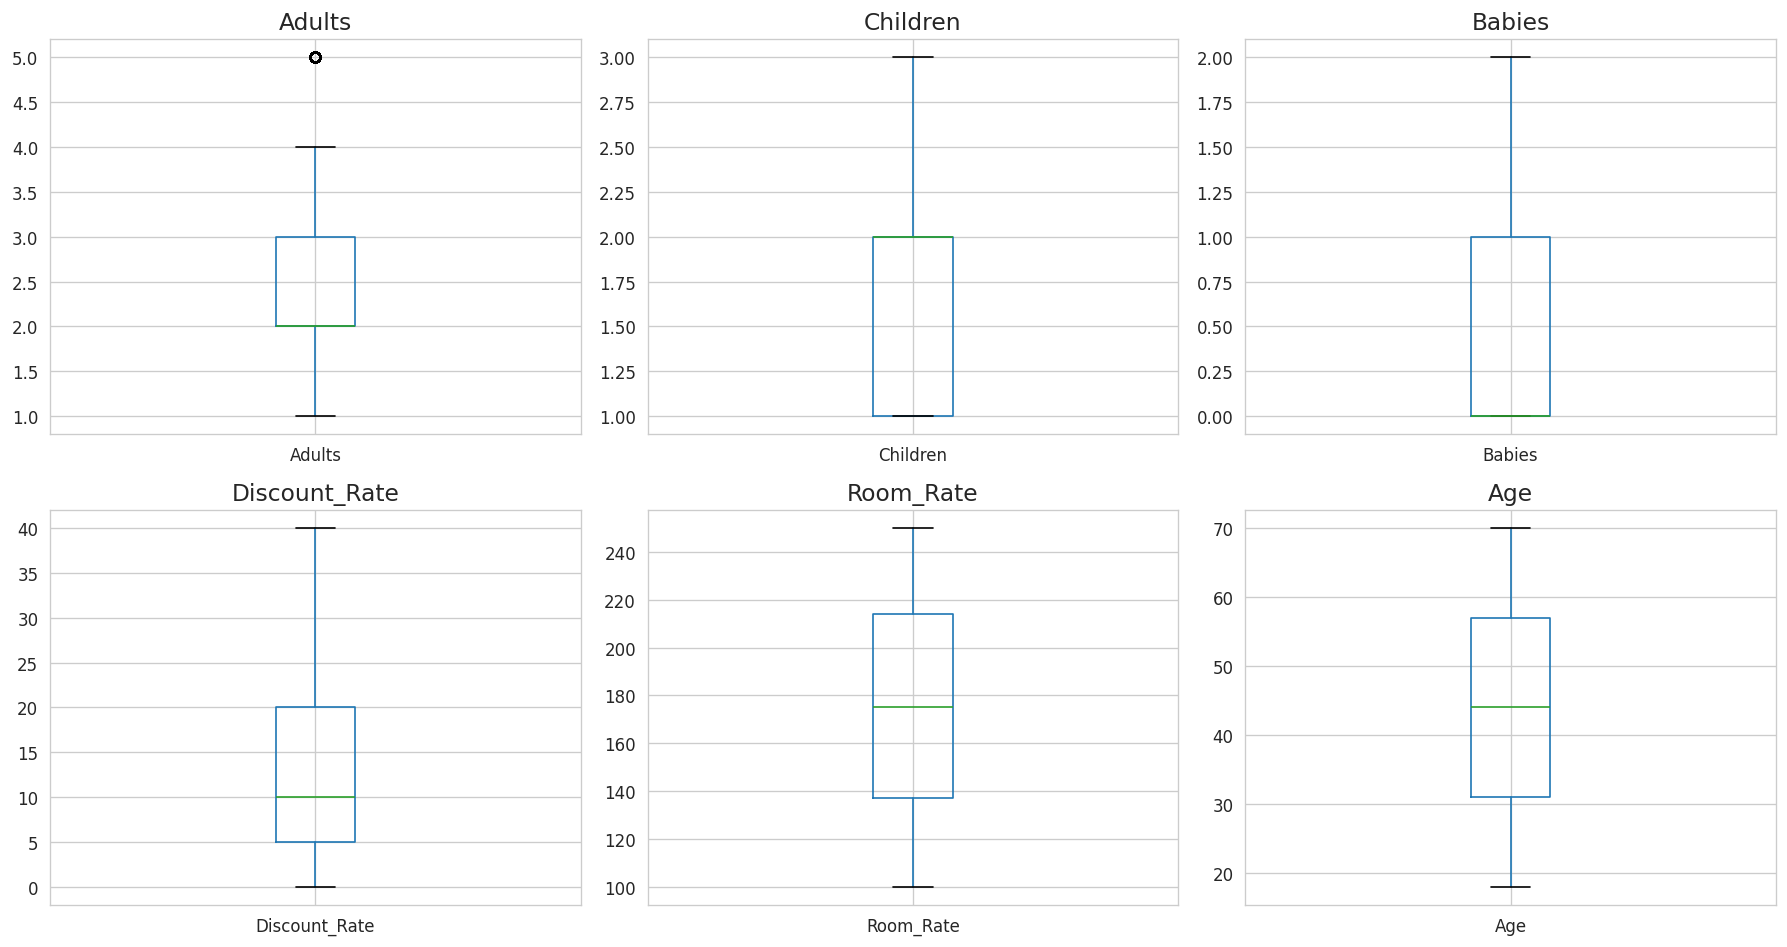

In [295]:
cols = ['Adults', 'Children', 'Babies', 'Discount_Rate', 'Room_Rate', 'Age']

plt.figure(figsize=(15, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)   # 2 rows, 3 columns
    train.boxplot(column=col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [296]:
# Cap outliers using IQR method
# Calculate from TRAIN only
Q1 = train['Adults'].quantile(0.25)
Q3 = train['Adults'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Apply to all datasets
for df in [train, validation, test]:
    df['Adults'] = df['Adults'].clip(lower, upper)

Inconsistent Categorical Values

In [297]:
train['Reservation_Status'].unique()

array(['checkout', 'canceled', 'no-show'], dtype=object)

In [298]:
train['Reservation_Status'].value_counts()

,count
Reservation_Status,
checkout,21240
canceled,4134
no-show,2125


In [299]:
# Investigating the Children column anomaly
print('=== Children Column Distribution ===')
print(train['Children'].value_counts().sort_index())

print('\n=== Children by Hotel Type ===')
print(train.groupby('Hotel_Type')['Children'].value_counts().unstack(fill_value=0))

print('\n=== Does 0 children exist? ===')
print('Bookings with 0 children:', (train['Children'] == 0).sum())
print('Total bookings:', len(train))
print('\nConclusion: No bookings have 0 children.')
print('This suggests the values (1, 2, 3) may represent category codes')
print('rather than actual counts of children per booking.')

=== Children Column Distribution ===
Children
1    11590
2    11362
3     4547
Name: count, dtype: int64

=== Children by Hotel Type ===
Children           1     2     3
Hotel_Type                      
Airport Hotels  3929  3807  1522
City Hotel      3877  3733  1524
Resort          3784  3822  1501

=== Does 0 children exist? ===
Bookings with 0 children: 0
Total bookings: 27499

Conclusion: No bookings have 0 children.
This suggests the values (1, 2, 3) may represent category codes
rather than actual counts of children per booking.


In [300]:
# Fix Ethnicity capitalisation inconsistency
for df in [train, validation, test]:
    df['Ethnicity'] = df['Ethnicity'].str.strip().str.title()

print('Ethnicity unique values after fix:')
print(train['Ethnicity'].unique())

Ethnicity unique values after fix:
['Latino' 'Caucasian' 'African American' 'Asian American']


In [301]:
# Fix Income spacing inconsistency
for df in [train, validation, test]:
    df['Income'] = df['Income'].str.strip().str.replace(r'\s*--\s*', '-', regex=True)

print('Income unique values after fix:')
print(train['Income'].unique())

Income unique values after fix:
['<25K' '50K-100K' '>100K' '25K-50K']


## **EDA (After Cleaning)**

Following data cleaning, a second round of EDA was performed focusing specifically on trends and patterns related to booking cancellations. This targeted analysis helped identify key factors influencing cancellation behaviour and provided more reliable insights after addressing data quality issues.

### Univariate Analysis

Identifying class Imbalance

In [302]:
# Class Imbalance Check
class_counts = train['Reservation_Status'].value_counts()
class_pct = train['Reservation_Status'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(2)
})

print("Class Distribution - Train Dataset")
print(class_summary)

Class Distribution - Train Dataset
                    Count  Percentage (%)
Reservation_Status                       
checkout            21240           77.24
canceled             4134           15.03
no-show              2125            7.73


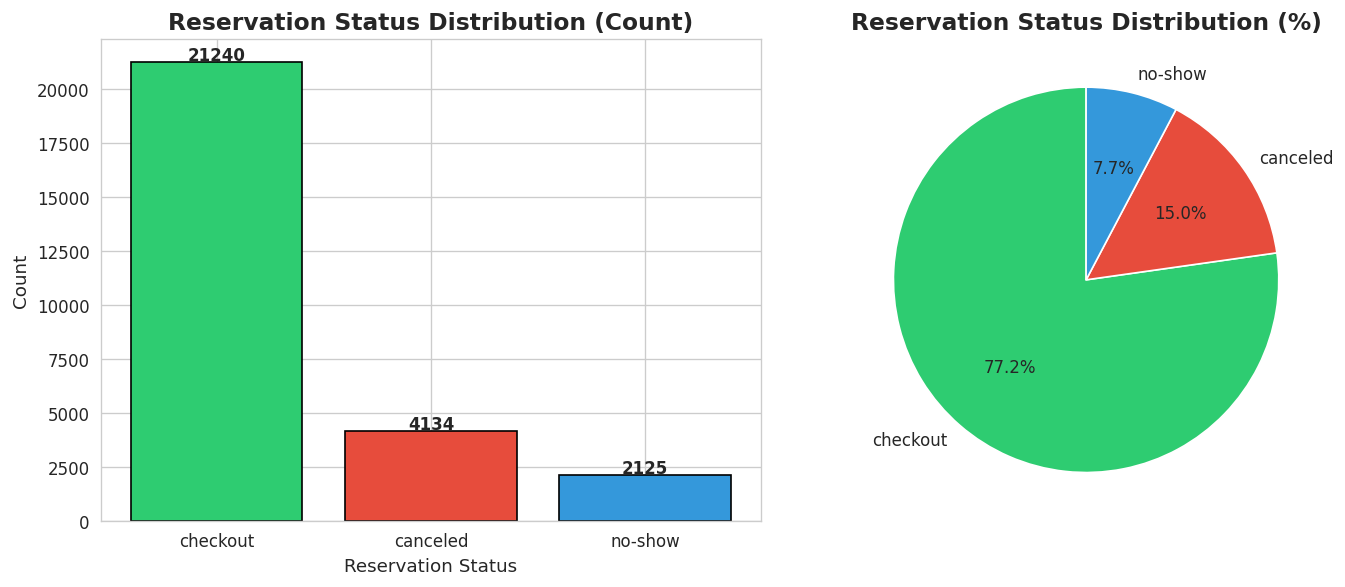

In [303]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values,
            color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black')
axes[0].set_title('Reservation Status Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Reservation Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c', '#3498db'],
            startangle=90)
axes[1].set_title('Reservation Status Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.show()

Numerical Analysis

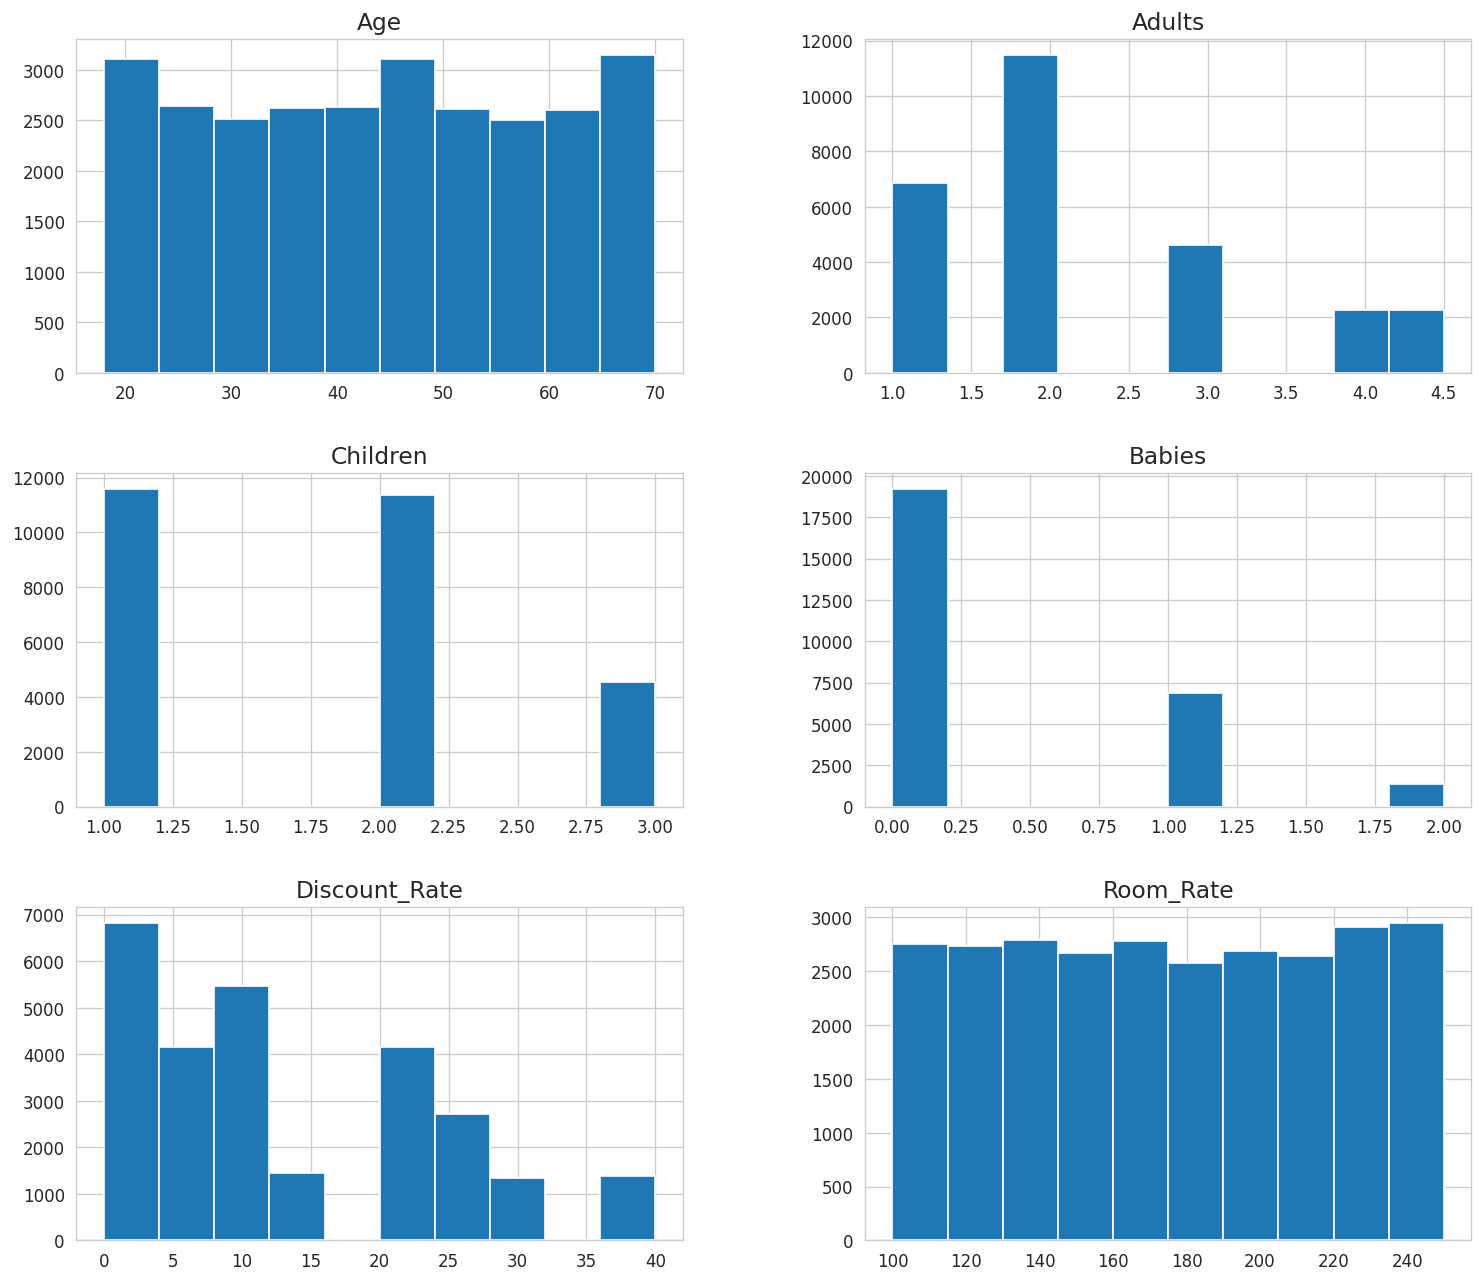

In [304]:
# Train dataset
num_cols = train.select_dtypes(include=['int64','float64']).columns
for col in ['Reservation-id', 'reservation-id']:
    if col in num_cols:
        num_cols = num_cols.drop([col])

train[num_cols].hist(figsize=(15,13))
plt.show()

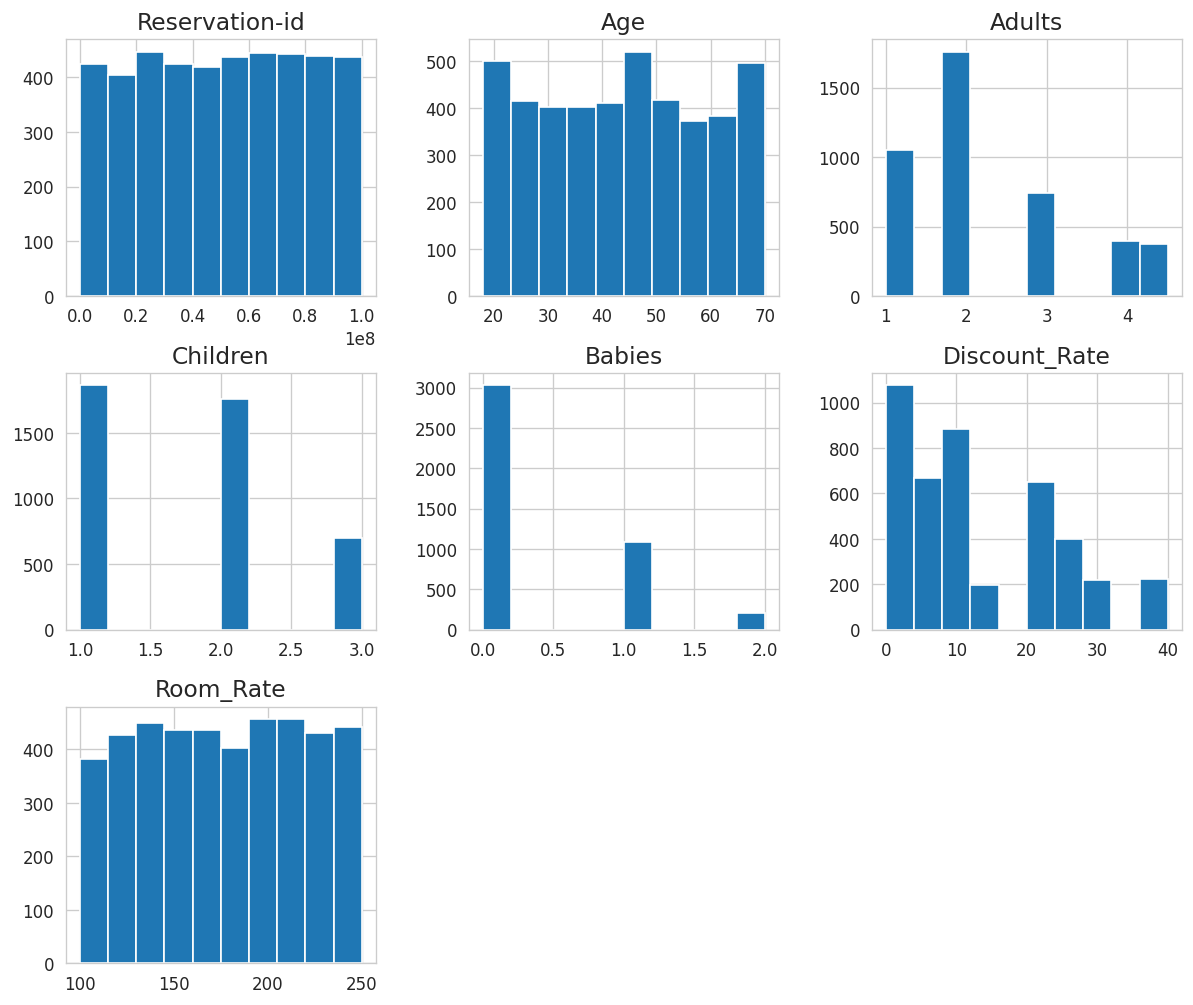

In [305]:
# Test dataset
num_cols = test.select_dtypes(include=['int64','float64']).columns

test[num_cols].hist(figsize=(12,10))
plt.show()

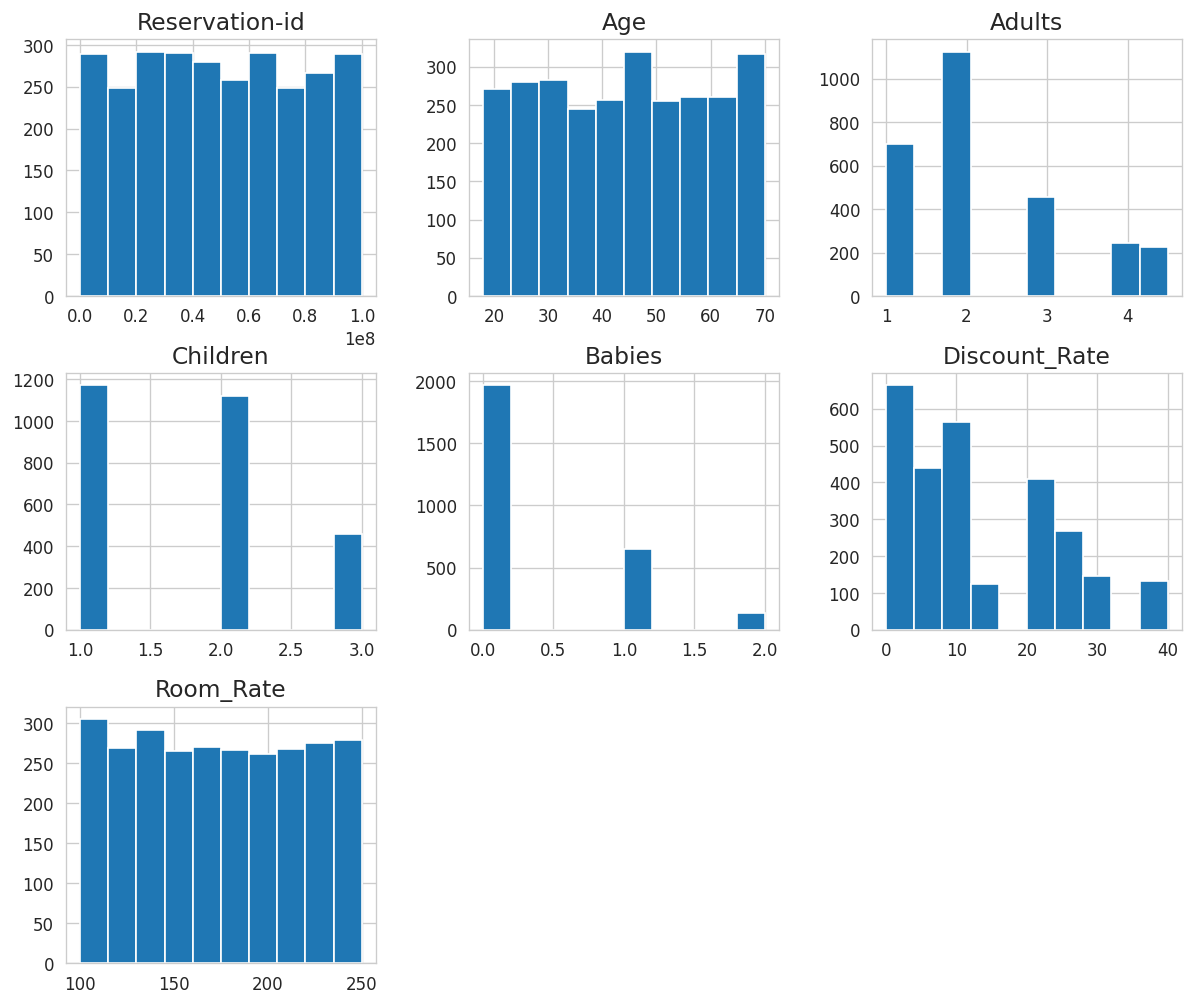

In [306]:
# Validation dataset
num_cols = validation.select_dtypes(include=['int64','float64']).columns
validation[num_cols].hist(figsize=(12,10))
plt.show()

Categorical Analysis

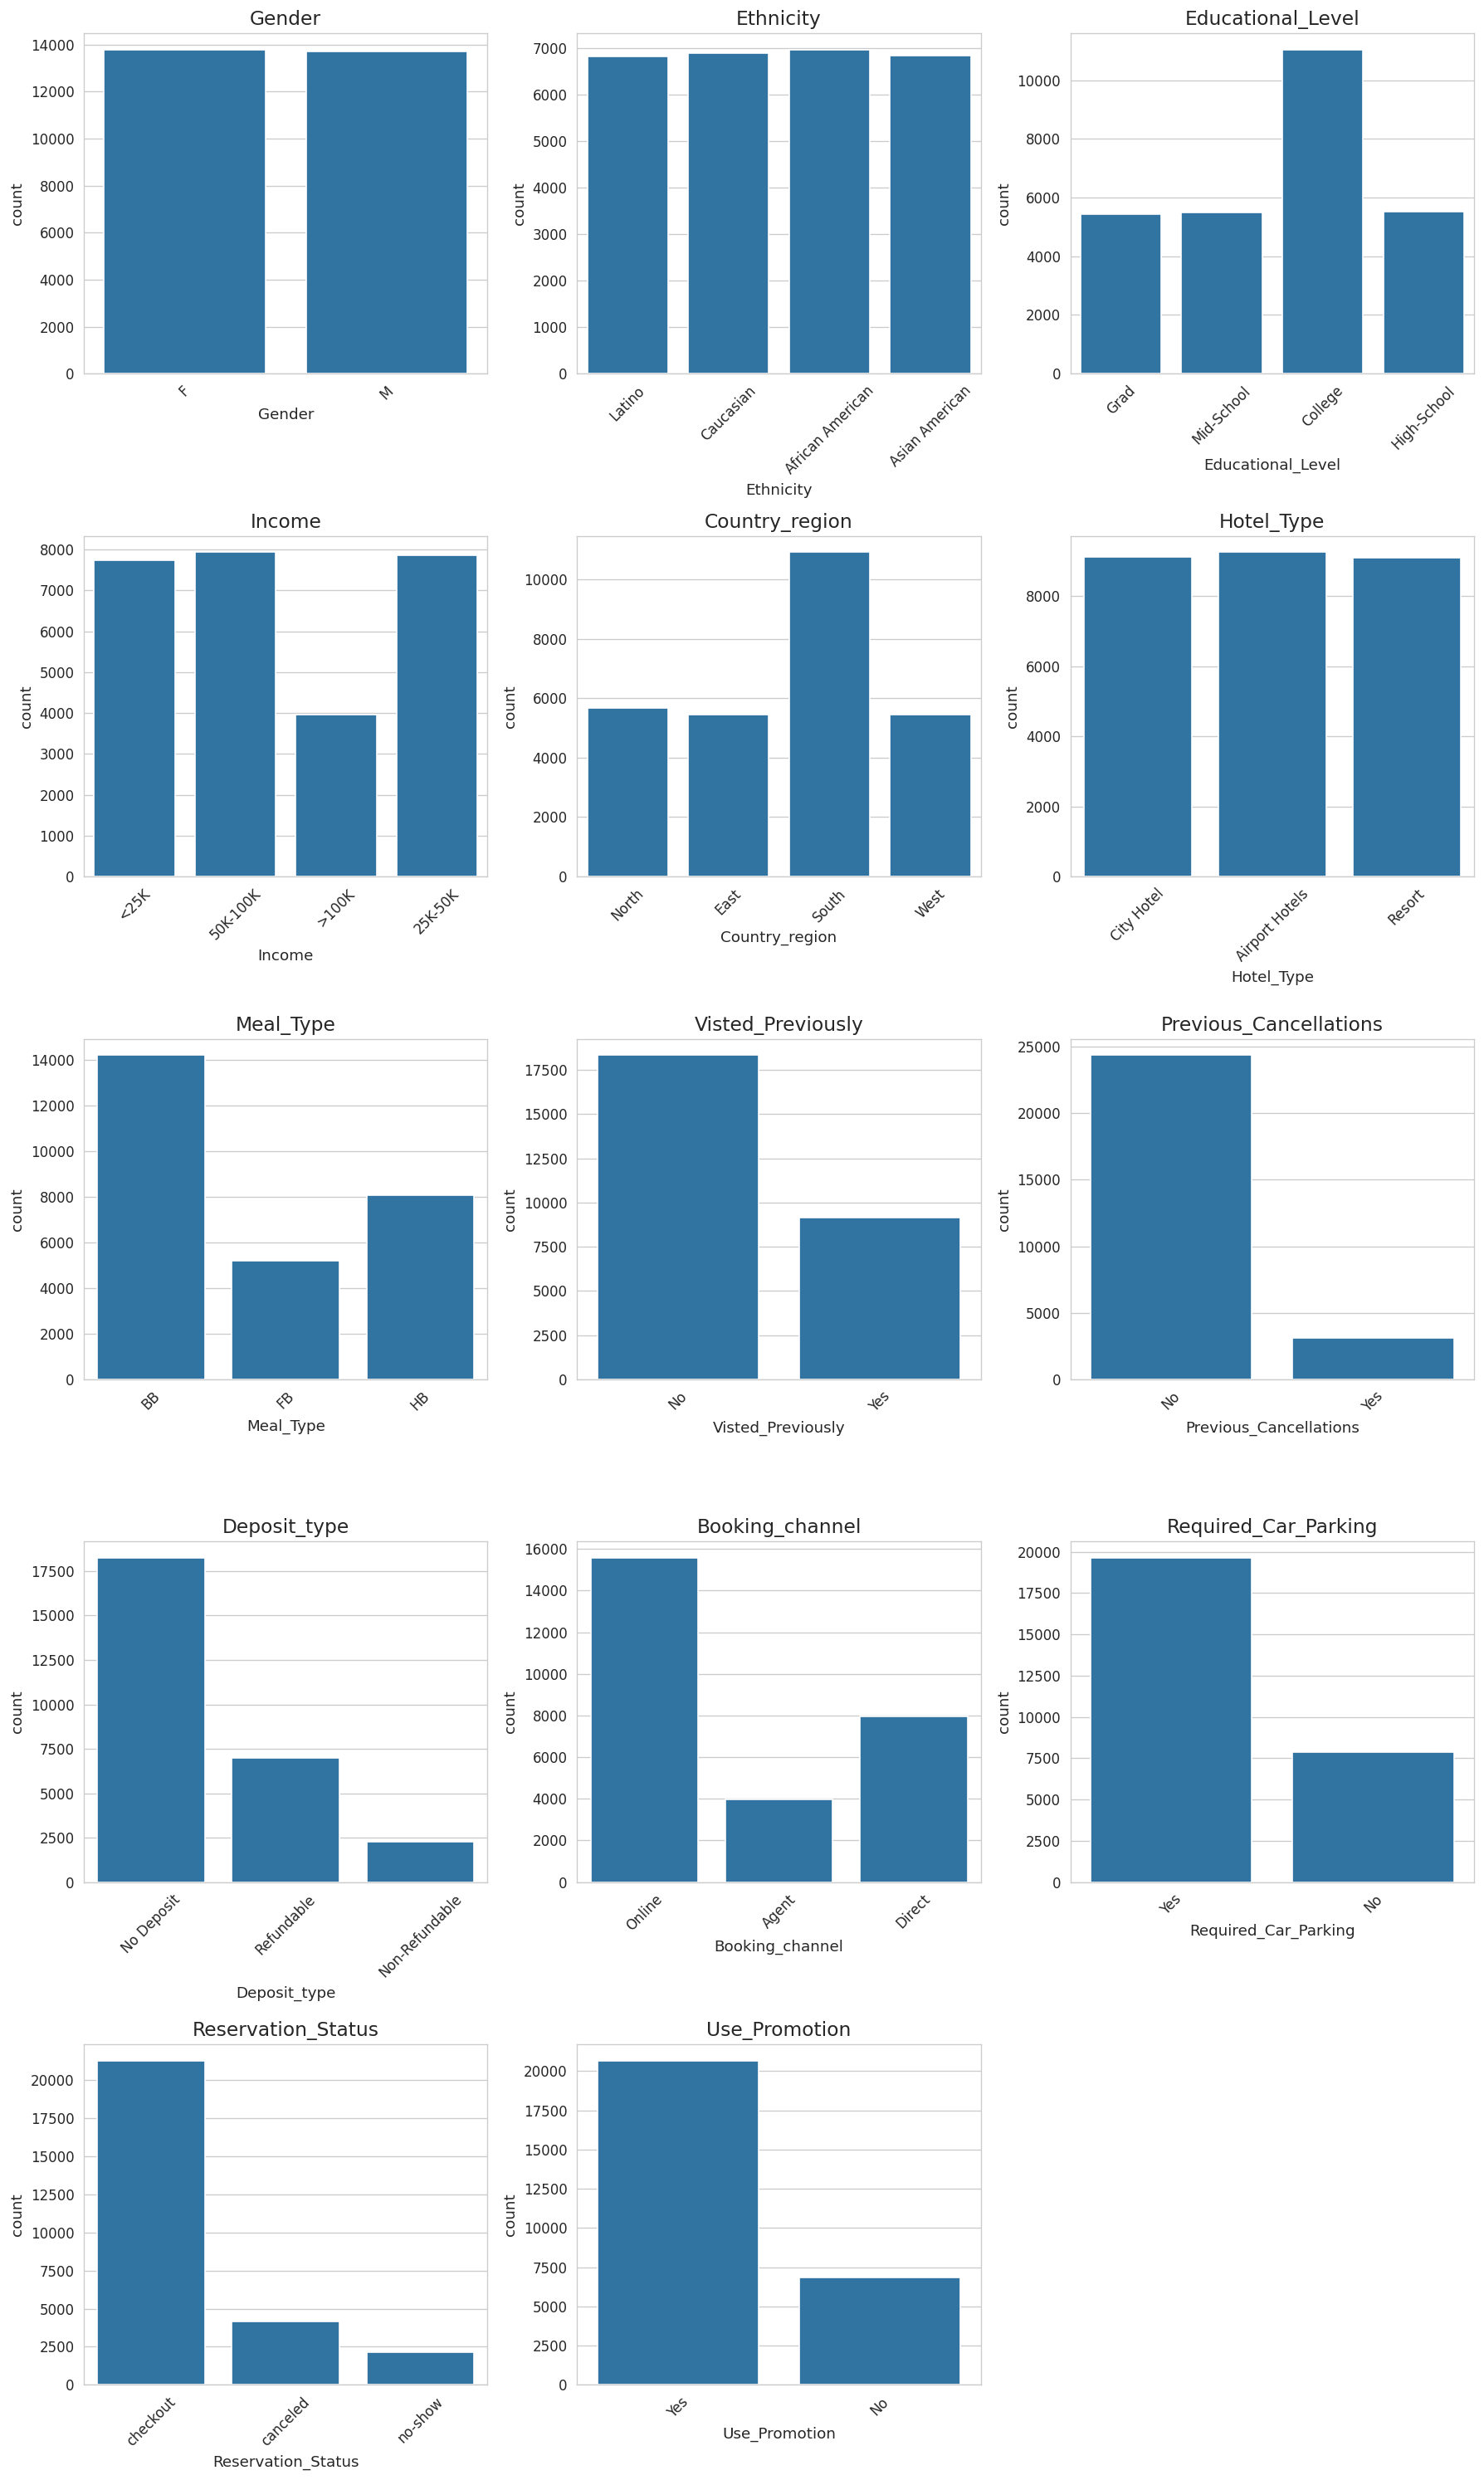

In [307]:
cat_cols = train.select_dtypes(include='object').columns

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=col, data=train)
    plt.title(f"{col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Reservation Status Distribution

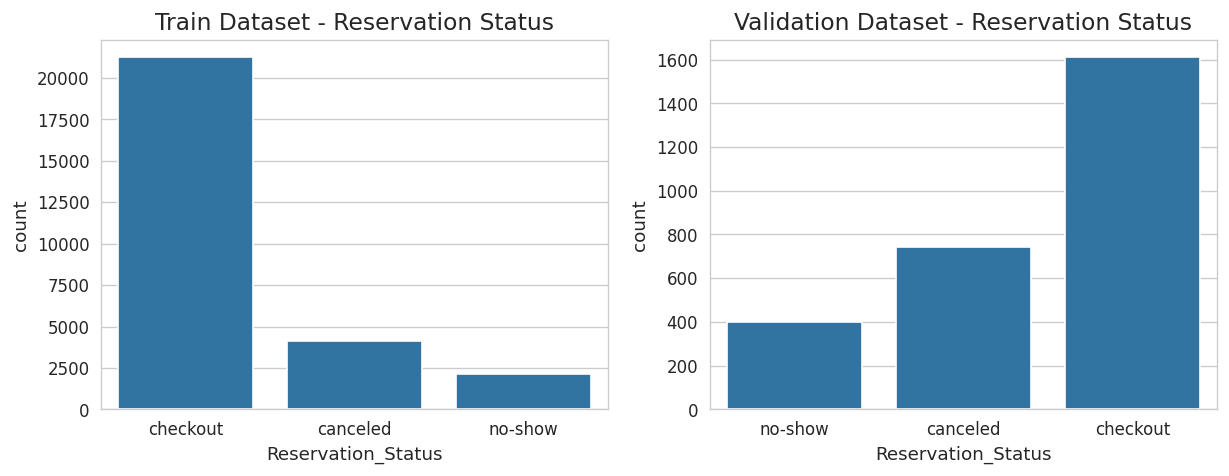

In [308]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x='Reservation_Status', data=train)
plt.title("Train Dataset - Reservation Status")

plt.subplot(1,2,2)
sns.countplot(x='Reservation_Status', data=validation)
plt.title("Validation Dataset - Reservation Status")

plt.show()

In [309]:
train.columns = train.columns.str.strip().str.lower()
validation.columns = validation.columns.str.strip().str.lower()
test.columns = test.columns.str.strip().str.lower()

Deposit Type Distribution

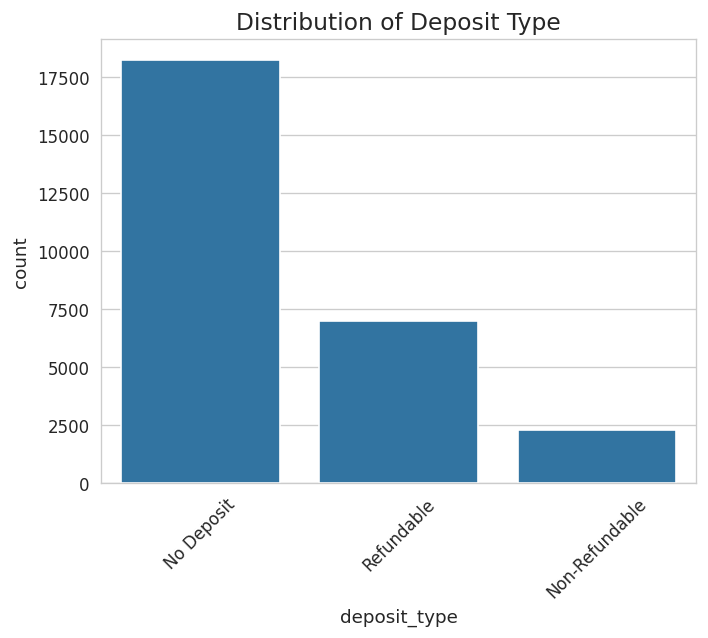

In [186]:
sns.countplot(x='deposit_type', data=train)
plt.title('Distribution of Deposit Type')
plt.xticks(rotation=45)
plt.show()

### Bivariate Analysis

In [310]:
train.columns = train.columns.str.strip().str.lower()

Previous Cancellations vs Reservation Status

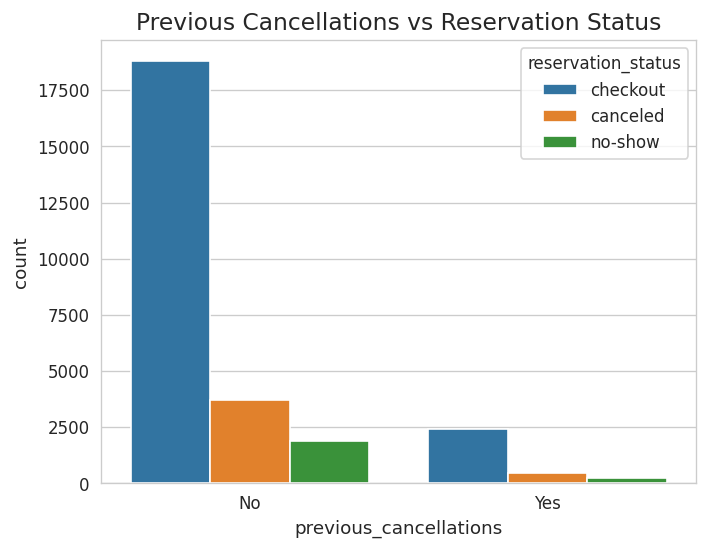

In [311]:
sns.countplot(x='previous_cancellations', hue='reservation_status', data=train)
plt.title('Previous Cancellations vs Reservation Status')
plt.show()

Room Rate vs Reservation Status

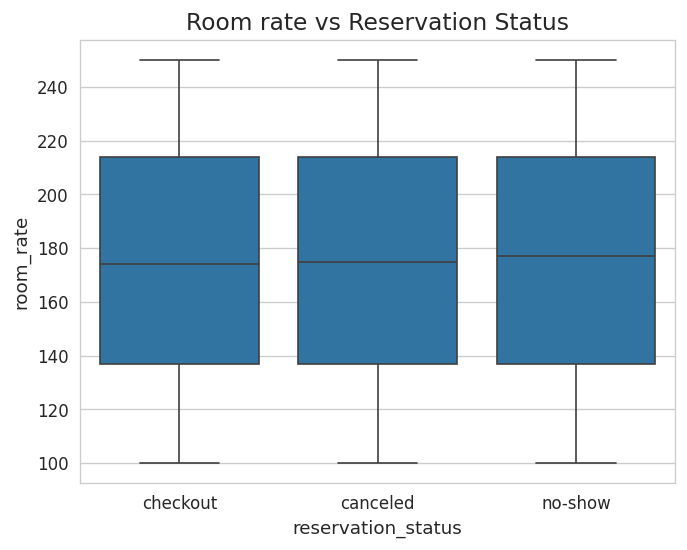

In [312]:
sns.boxplot(x='reservation_status', y='room_rate', data=train)
plt.title("Room rate vs Reservation Status")
plt.show()

Visited Previously vs Reservation Status

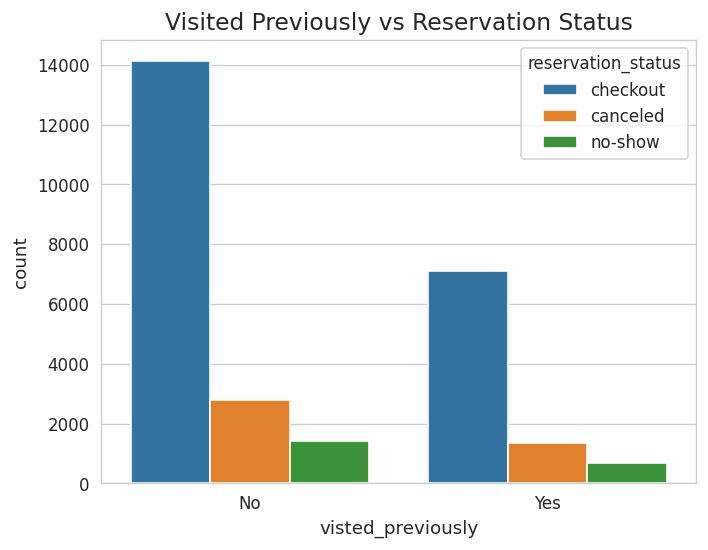

In [313]:
sns.countplot(x='visted_previously', hue='reservation_status', data=train)
plt.title('Visited Previously vs Reservation Status')
plt.show()

Hotel Type vs Reservation Status

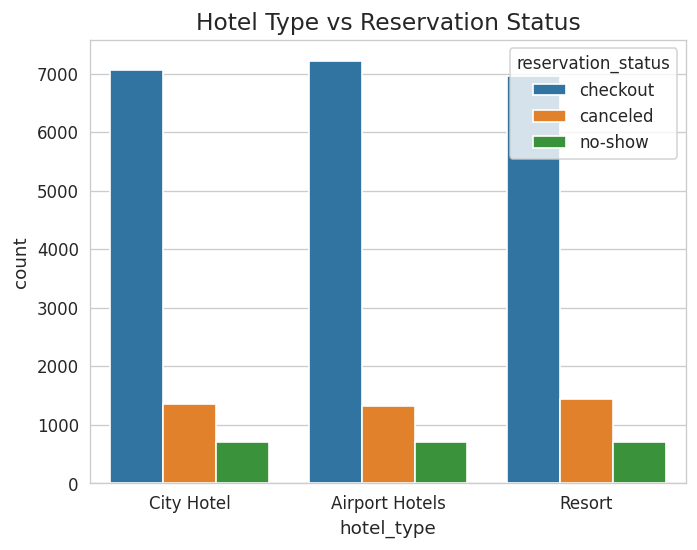

In [314]:
sns.countplot(x='hotel_type', hue='reservation_status', data=train)
plt.title("Hotel Type vs Reservation Status")
plt.show()


=== Airport Hotels ===


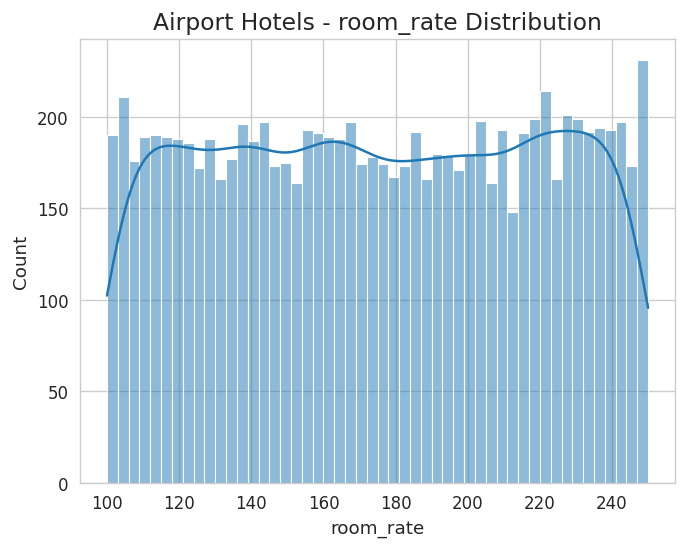

room_rate is approximately normal (skewness: -0.01)


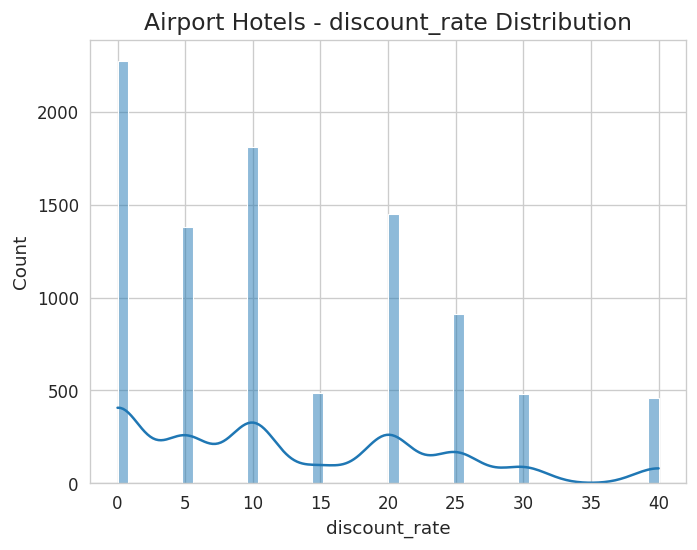

discount_rate is approximately normal (skewness: 0.69)


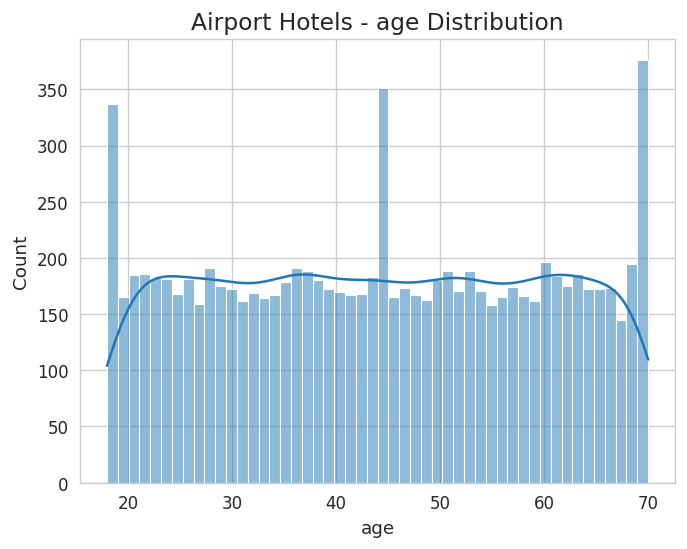

age is approximately normal (skewness: 0.00)


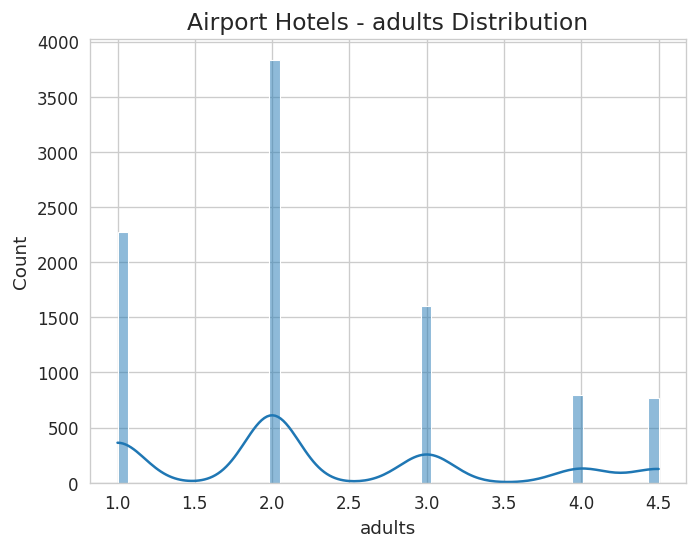

adults is approximately normal (skewness: 0.61)


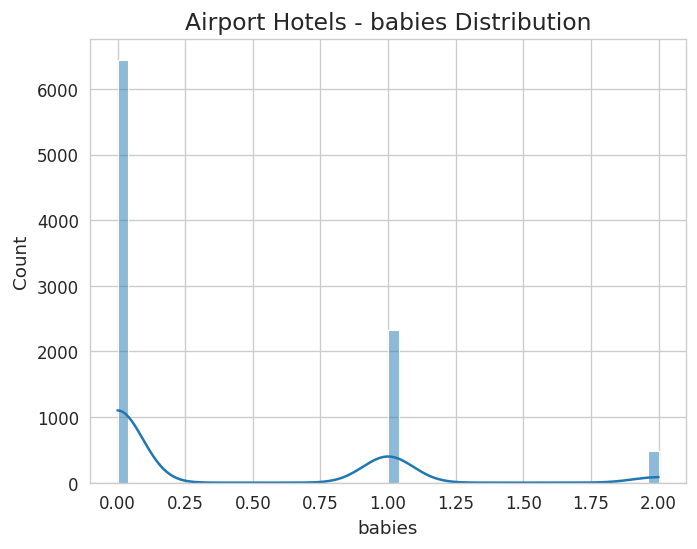

babies is right skewed (skewness: 1.39)

=== City Hotel ===


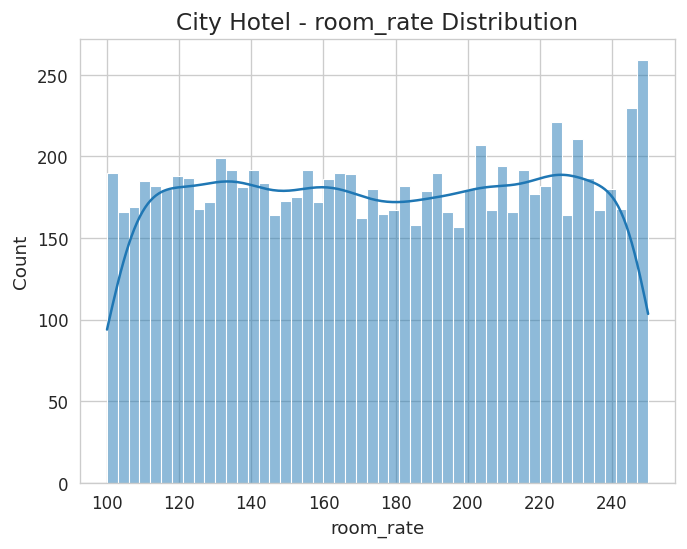

room_rate is approximately normal (skewness: -0.01)


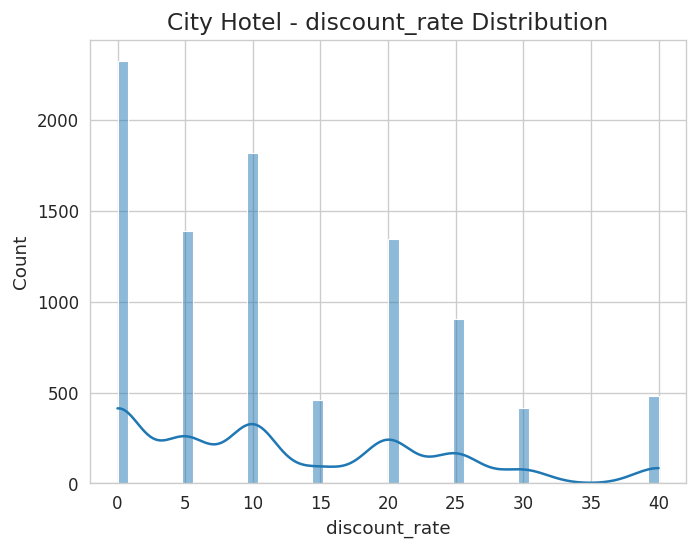

discount_rate is approximately normal (skewness: 0.75)


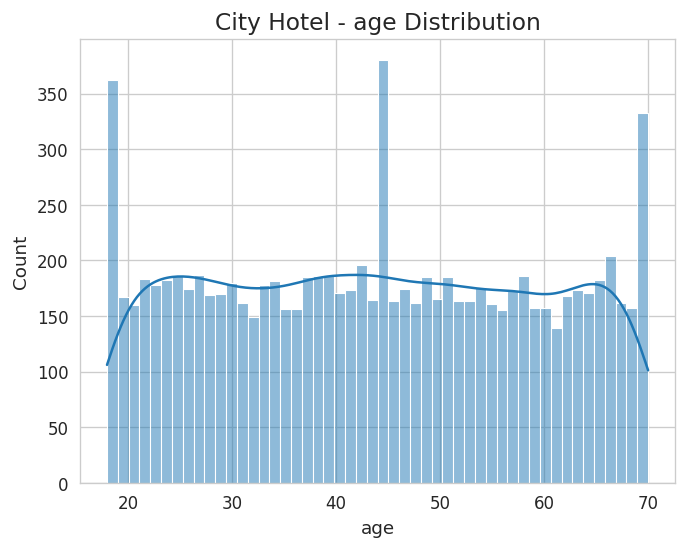

age is approximately normal (skewness: 0.02)


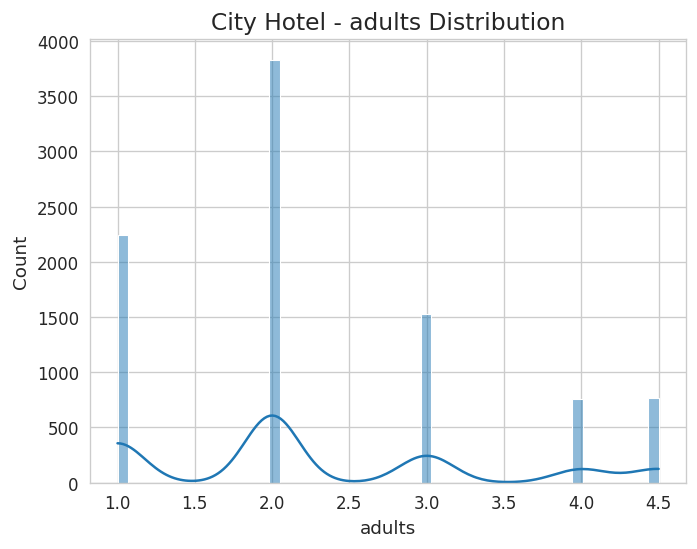

adults is approximately normal (skewness: 0.63)


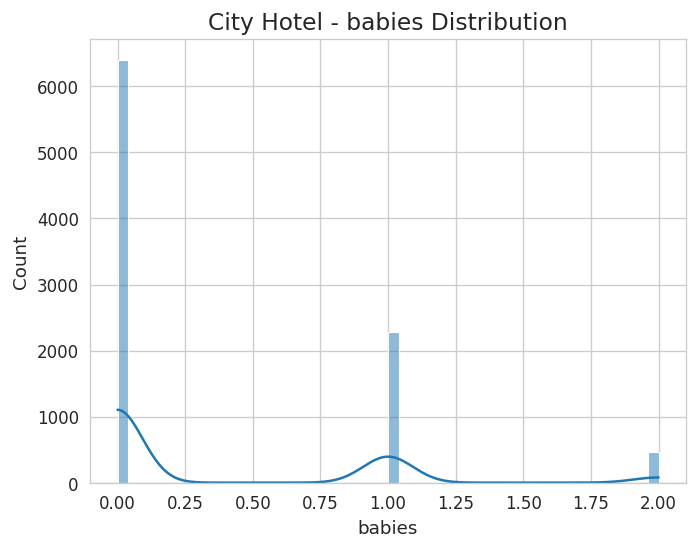

babies is right skewed (skewness: 1.41)

=== Resort ===


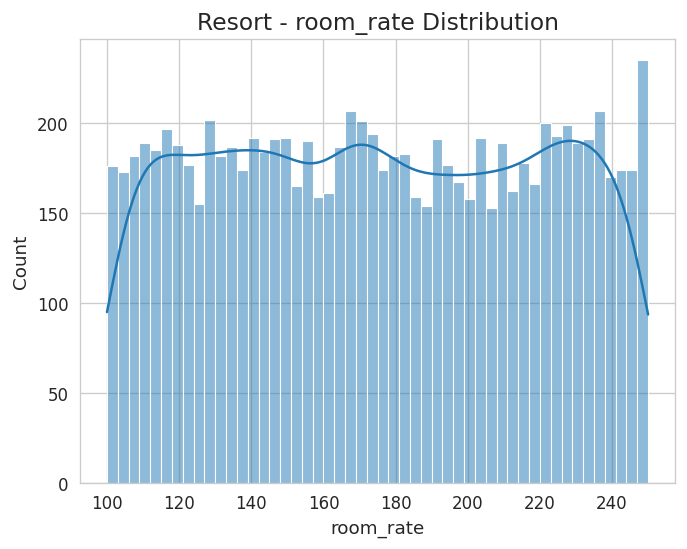

room_rate is approximately normal (skewness: 0.01)


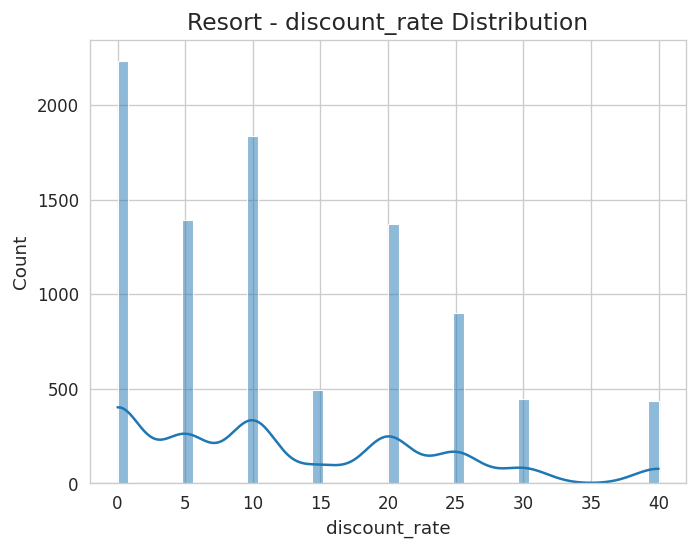

discount_rate is approximately normal (skewness: 0.72)


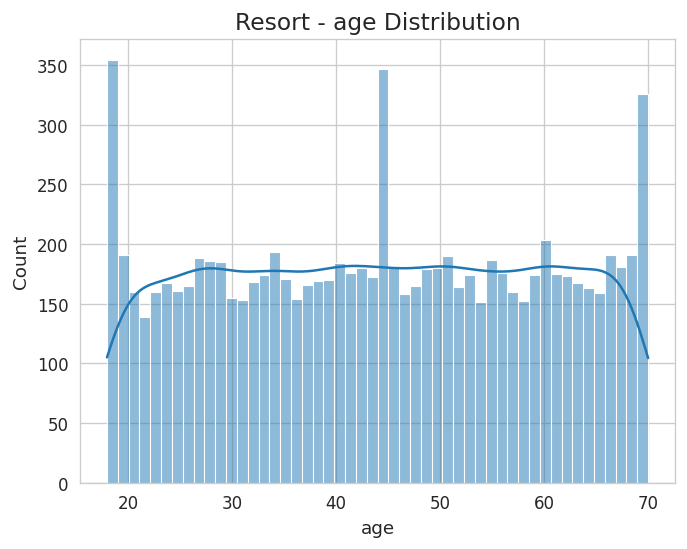

age is approximately normal (skewness: -0.01)


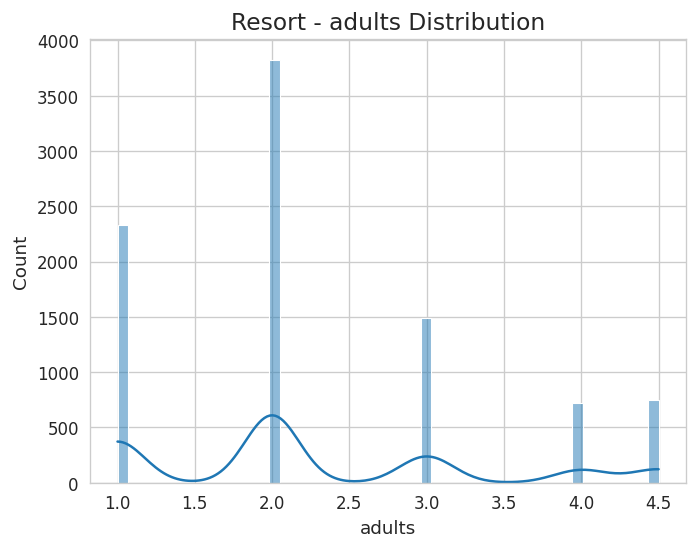

adults is approximately normal (skewness: 0.67)


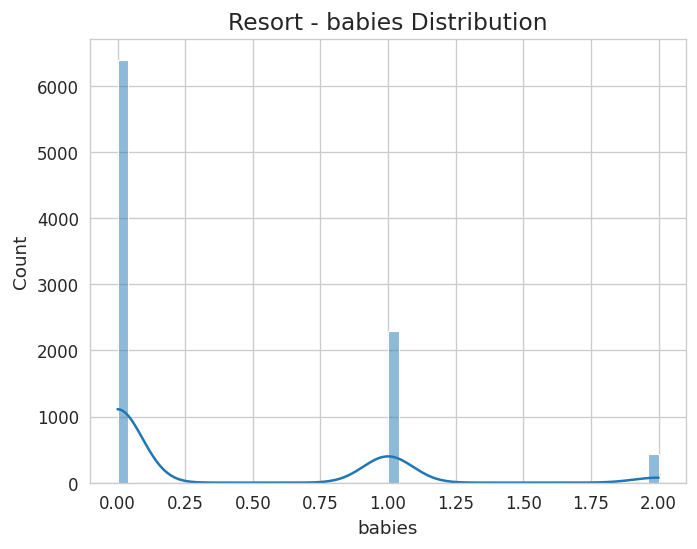

babies is right skewed (skewness: 1.41)


In [315]:
# Distribution of numerical variables by Hotel Type
hotel_types = ['Airport Hotels', 'City Hotel', 'Resort']
num_features = ['room_rate', 'discount_rate', 'age', 'adults', 'babies']

for hotel in hotel_types:
    hotel_data = train[train['hotel_type'] == hotel]

    print(f'\n=== {hotel} ===')

    for feature in num_features:
        sns.histplot(hotel_data[feature], bins=50, kde=True)
        plt.title(f'{hotel} - {feature} Distribution')
        plt.xlabel(feature)
        plt.ylabel('Count')
        plt.show()

        skewness = hotel_data[feature].skew()
        if skewness > 1:
            print(f'{feature} is right skewed (skewness: {skewness:.2f})')
        elif skewness < -1:
            print(f'{feature} is left skewed (skewness: {skewness:.2f})')
        else:
            print(f'{feature} is approximately normal (skewness: {skewness:.2f})')

Distribution for each Hotel Type separately

In [316]:
# Distribution of key variables for each Hotel Type
hotel_types = train['hotel_type'].unique()

for hotel in hotel_types:
    hotel_data = train[train['hotel_type'] == hotel]
    total = len(hotel_data)
    cancellations = (hotel_data['reservation_status'] == 'canceled').sum()
    no_shows = (hotel_data['reservation_status'] == 'no-show').sum()
    checkouts = (hotel_data['reservation_status'] == 'checkout').sum()

    print(f'\n=== {hotel} ===')
    print(f'Total Bookings    : {total}')
    print(f'Cancellations     : {cancellations} ({cancellations/total*100:.1f}%)')
    print(f'No-Shows          : {no_shows} ({no_shows/total*100:.1f}%)')
    print(f'Checkouts         : {checkouts} ({checkouts/total*100:.1f}%)')


=== City Hotel ===
Total Bookings    : 9134
Cancellations     : 1362 (14.9%)
No-Shows          : 715 (7.8%)
Checkouts         : 7057 (77.3%)

=== Airport Hotels ===
Total Bookings    : 9258
Cancellations     : 1330 (14.4%)
No-Shows          : 709 (7.7%)
Checkouts         : 7219 (78.0%)

=== Resort ===
Total Bookings    : 9107
Cancellations     : 1442 (15.8%)
No-Shows          : 701 (7.7%)
Checkouts         : 6964 (76.5%)


Count of customers in each segment per hotel type

Count of Customers in Each Segment per Hotel Type
reservation_status  canceled  checkout  no-show
hotel_type                                     
Airport Hotels          1330      7219      709
City Hotel              1362      7057      715
Resort                  1442      6964      701
Count of Customers in Each Segment per Hotel Type
reservation_status  canceled  checkout  no-show
hotel_type                                     
Airport Hotels          1330      7219      709
City Hotel              1362      7057      715
Resort                  1442      6964      701


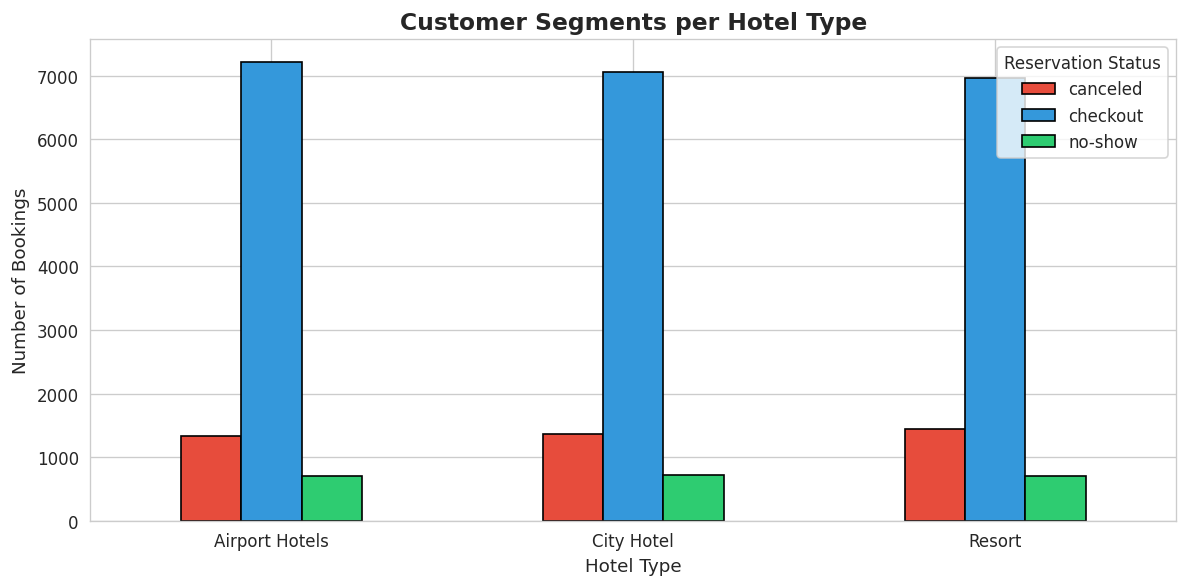

In [317]:
# Count of customers in each segment per hotel type
segment_hotel = train.groupby(['hotel_type', 'reservation_status']).size().unstack(fill_value=0)

print("Count of Customers in Each Segment per Hotel Type")
print(segment_hotel)

# Visual
segment_hotel = train.groupby(['hotel_type', 'reservation_status']).size().unstack(fill_value=0)

print("Count of Customers in Each Segment per Hotel Type")
print(segment_hotel)

# Plot
segment_hotel.plot(kind='bar', figsize=(10, 5),
                   color=['#e74c3c', '#3498db', '#2ecc71'],
                   edgecolor='black')
plt.title('Customer Segments per Hotel Type', fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)
plt.legend(title='Reservation Status')
plt.tight_layout()
plt.show()

Age group vs Reservation Status

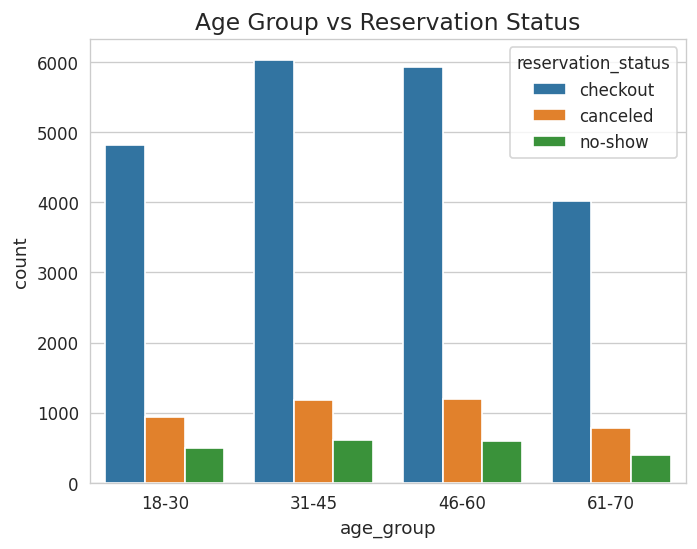

In [318]:
train['age_group'] = pd.cut(train['age'],
                             bins=[18, 30, 45, 60, 70],
                             labels=['18-30', '31-45', '46-60', '61-70'])

sns.countplot(x='age_group', hue='reservation_status', data=train)
plt.title('Age Group vs Reservation Status')
plt.show()

Meal Type vs Reservation Status

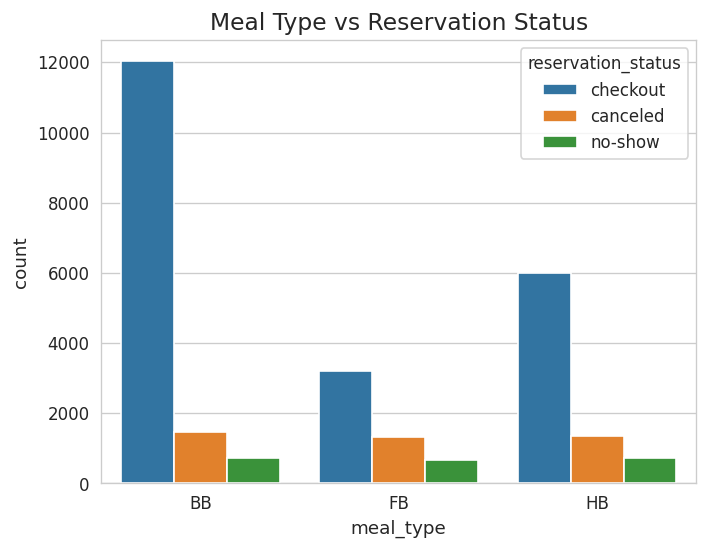

In [319]:
sns.countplot(x='meal_type', hue='reservation_status', data=train)
plt.title('Meal Type vs Reservation Status')
plt.show()

Country Region vs Reservation Status

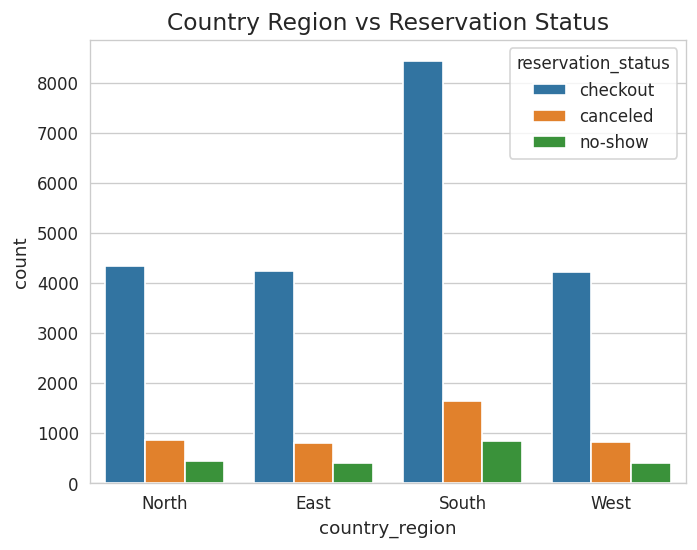

In [320]:
sns.countplot(x='country_region', hue='reservation_status', data=train)
plt.title('Country Region vs Reservation Status')
plt.show()

Gender vs Reservation Status

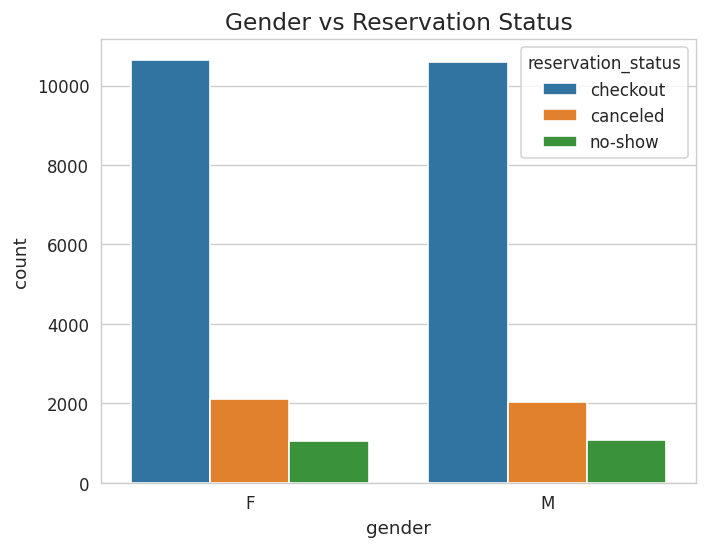

In [321]:
sns.countplot(x='gender', hue='reservation_status', data=train)
plt.title('Gender vs Reservation Status')
plt.show()

Required Car Parking vs Reservation Status

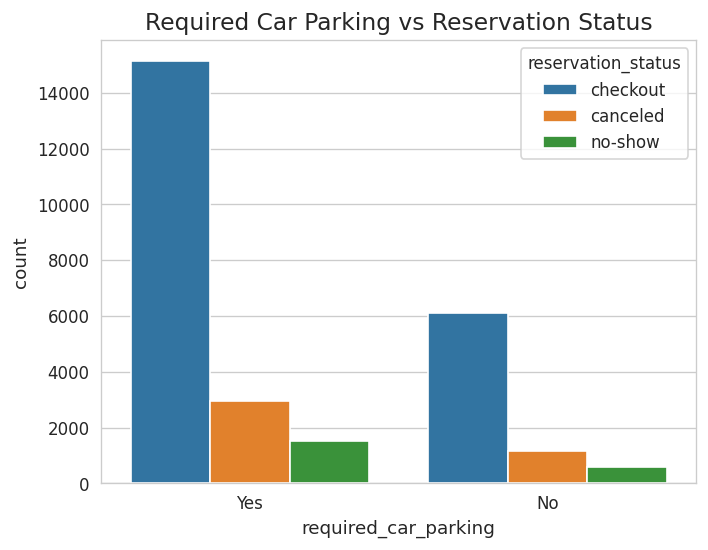

In [322]:
sns.countplot(x='required_car_parking', hue='reservation_status', data=train)
plt.title('Required Car Parking vs Reservation Status')
plt.show()

Customer Type vs Reservation Status

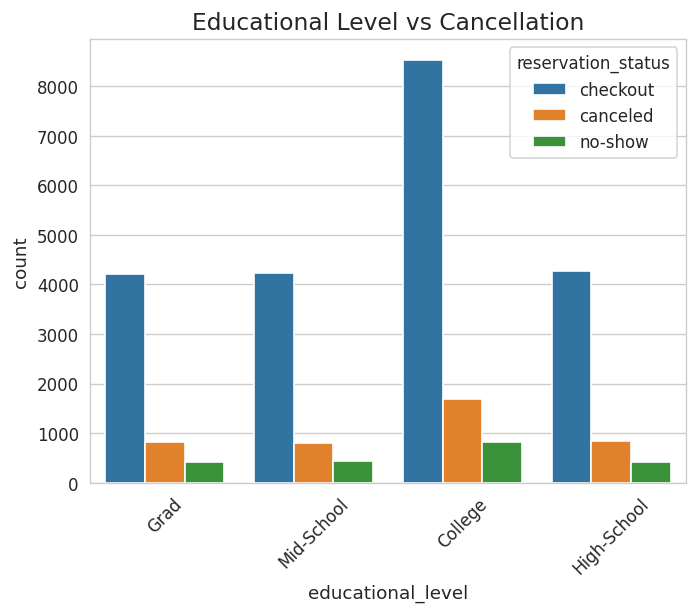

In [323]:
sns.countplot(x='educational_level', hue='reservation_status', data=train)
plt.xticks(rotation=45)
plt.title("Educational Level vs Cancellation")
plt.show()

Deposit Type vs Reservation Status

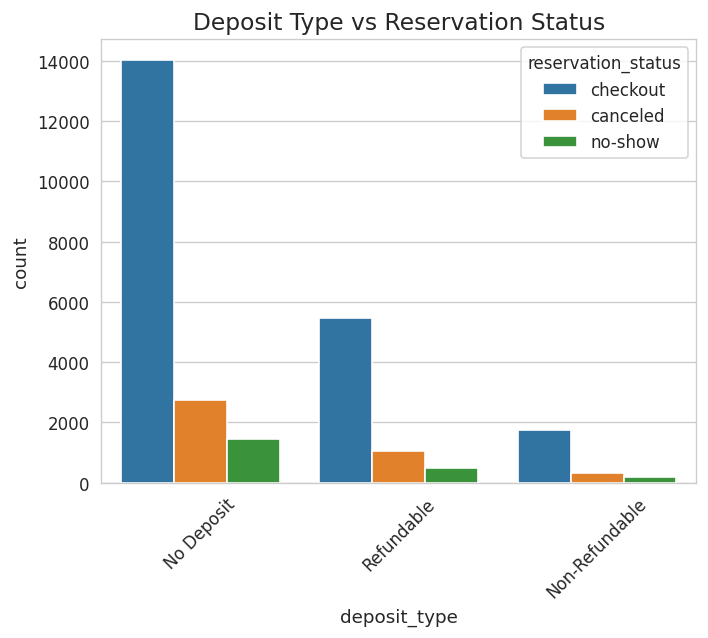

In [324]:
sns.countplot(x='deposit_type', hue='reservation_status', data=train)
plt.title('Deposit Type vs Reservation Status')
plt.xticks(rotation=45)
plt.show()

### Multivariate Analysis

#### Cluster Analysis

Hotel Type vs Booking Channel vs Reservation Status

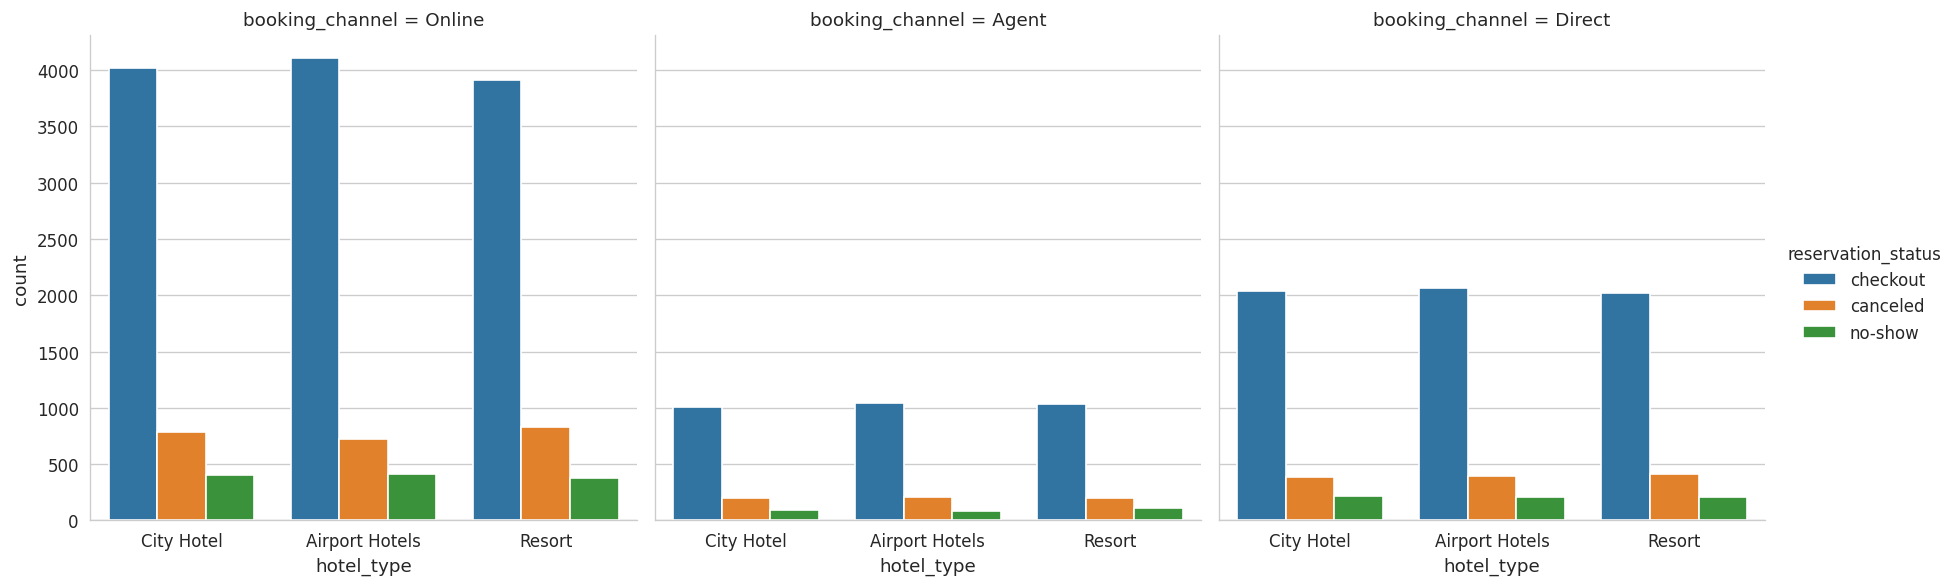

In [325]:
sns.catplot(
    x='hotel_type',
    hue='reservation_status',
    col='booking_channel',
    kind='count',
    data=train
)

plt.show()

Correlation Matrix

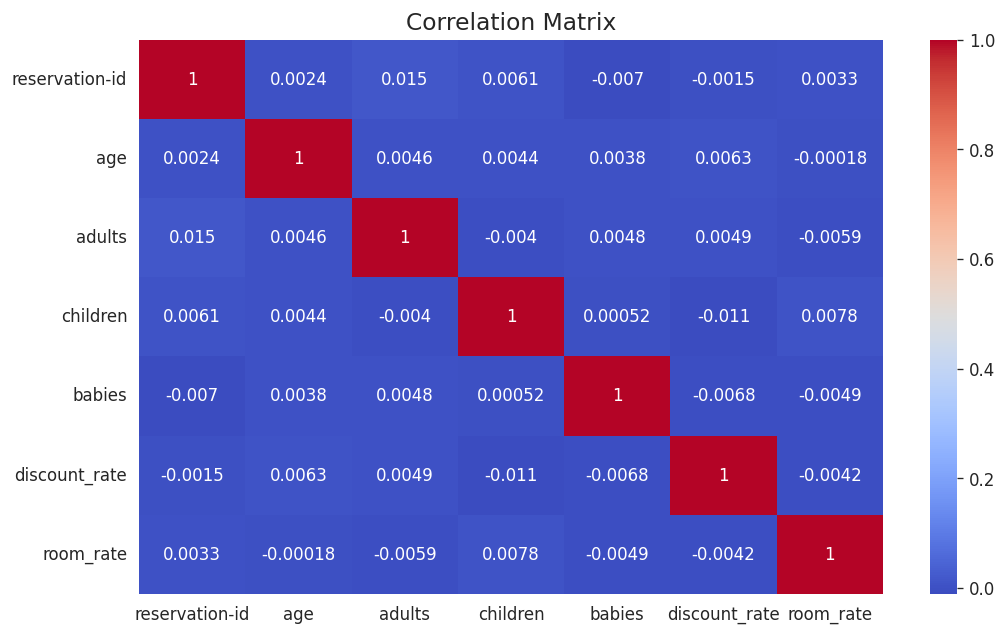

In [326]:
plt.figure(figsize=(10,6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Lead Time + Deposit Type vs Reservation Status

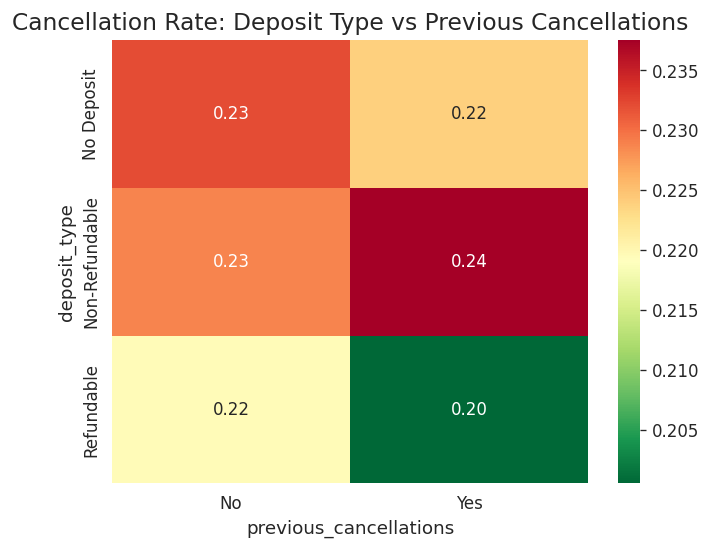

In [327]:
#Creating a varible for no shows and cancelled
train['is_lost_booking'] = train['reservation_status'].isin(['canceled', 'no-show']).astype(int)

pivot = train.groupby(['deposit_type', 'previous_cancellations'])['is_lost_booking'].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r')
plt.title('Cancellation Rate: Deposit Type vs Previous Cancellations')
plt.show()

Age Group + Hotel Type vs Reservation Status

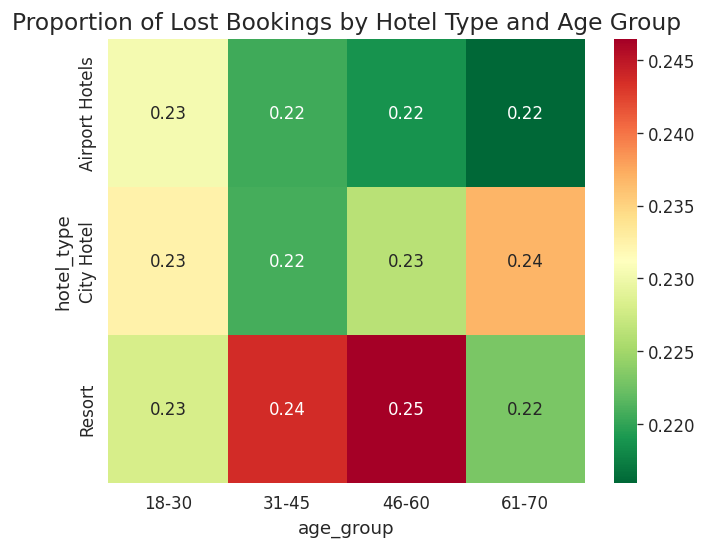

In [328]:
age_hotel = train.groupby(['hotel_type', 'age_group'], observed=False)['is_lost_booking'].mean().unstack()
sns.heatmap(age_hotel, annot=True, fmt='.2f', cmap='RdYlGn_r')
plt.title('Proportion of Lost Bookings by Hotel Type and Age Group')
plt.show()

## **Revenue Loss Analysis**

Standardize Reservation Status label in the Validation dataset

In [329]:
# Standardize reservation status in validation
validation['reservation_status'] = validation['reservation_status'].str.lower().str.strip()
validation['reservation_status'] = validation['reservation_status'].replace({'check-in': 'checkout', 'check-out': 'checkout'})

print("\nUnique statuses in train:")
print(train['reservation_status'].unique())

print("\nUnique statuses in validation:")
print(validation['reservation_status'].unique())


Unique statuses in train:
['checkout' 'canceled' 'no-show']

Unique statuses in validation:
['no-show' 'canceled' 'checkout']


Create Length of Stay

In [330]:
for df in [train, validation, test]:
    df['Length_of_Stay'] = (df['expected_checkout'] - df['expected_checkin']).dt.days

# If any value is 0 or negative, force minimum stay to 1
for df in [train, validation, test]:
    df['Length_of_Stay'] = df['Length_of_Stay'].clip(lower=1)

print("\nLength of Stay summary - Train")
print(train['Length_of_Stay'].describe())

print("\nLength of Stay summary - Validation")
print(validation['Length_of_Stay'].describe())

print("\nLength of Stay summary - Test")
print(test['Length_of_Stay'].describe())


Length of Stay summary - Train
count    27499.000000
mean         1.836212
std          0.985204
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          4.000000
Name: Length_of_Stay, dtype: float64

Length of Stay summary - Validation
count    2749.000000
mean        1.797381
std         0.973847
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: Length_of_Stay, dtype: float64

Length of Stay summary - Test
count    4318.000000
mean        1.821214
std         0.975728
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max         4.000000
Name: Length_of_Stay, dtype: float64


Calculate Gross Revenue

In [332]:
for df in [train, validation, test]:
    df['Gross_Revenue'] = df['room_rate'] * df['Length_of_Stay']

print("\nTrain Gross Revenue sample:")
print(train[['room_rate', 'Length_of_Stay', 'Gross_Revenue']].head())


Train Gross Revenue sample:
   room_rate  Length_of_Stay  Gross_Revenue
0        218               1            218
1        185               1            185
2        119               4            476
3        144               1            144
4        242               1            242


Calculate Net Revenue after discount

In [333]:
for df in [train, validation, test]:
    df['Net_Revenue'] = np.where(
        df['use_promotion'] == 'Yes',
        df['Gross_Revenue'] * (1 - df['discount_rate'] / 100),
        df['Gross_Revenue']
    )

print("\nTrain Net Revenue sample:")
print(train[['Gross_Revenue', 'use_promotion', 'discount_rate', 'Net_Revenue']].head())


Train Net Revenue sample:
   Gross_Revenue use_promotion  discount_rate  Net_Revenue
0            218           Yes             10        196.2
1            185            No              0        185.0
2            476            No              0        476.0
3            144           Yes              5        136.8
4            242           Yes             10        217.8


Create Revenue Loss column

In [334]:
# Revenue loss only for Canceled and No-Show
train['Revenue_Loss'] = np.where(
    train['reservation_status'].isin(['canceled', 'no-show']),
    train['Net_Revenue'],
    0
)

validation['Revenue_Loss'] = np.where(
    validation['reservation_status'].isin(['canceled', 'no-show']),
    validation['Net_Revenue'],
    0
)

print("\nTrain Revenue Loss sample:")
print(train[['reservation_status', 'Net_Revenue', 'Revenue_Loss']].head())

print("\nValidation Revenue Loss sample:")
print(validation[['reservation_status', 'Net_Revenue', 'Revenue_Loss']].head())


Train Revenue Loss sample:
  reservation_status  Net_Revenue  Revenue_Loss
0           checkout        196.2           0.0
1           checkout        185.0           0.0
2           checkout        476.0           0.0
3           checkout        136.8           0.0
4           checkout        217.8           0.0

Validation Revenue Loss sample:
  reservation_status  Net_Revenue  Revenue_Loss
0            no-show        326.4         326.4
1           canceled        748.0         748.0
2           canceled        204.3         204.3
3           checkout        283.5           0.0
4           checkout        196.2           0.0


Total Revenue Loss

In [335]:
train_total_loss = train['Revenue_Loss'].sum()
validation_total_loss = validation['Revenue_Loss'].sum()

print("\nTotal Revenue Loss")
print("Train Dataset:", round(train_total_loss, 2))
print("Validation Dataset:", round(validation_total_loss, 2))


Total Revenue Loss
Train Dataset: 1754664.2
Validation Dataset: 311383.55


Revenue Loss Percentage

In [336]:
train_loss_pct = (train['Revenue_Loss'].sum() / train['Net_Revenue'].sum()) * 100
validation_loss_pct = (validation['Revenue_Loss'].sum() / validation['Net_Revenue'].sum()) * 100

print("\nRevenue Loss Percentage")
print("Train Dataset:", round(train_loss_pct, 2), "%")
print("Validation Dataset:", round(validation_loss_pct, 2), "%")


Revenue Loss Percentage
Train Dataset: 22.71 %
Validation Dataset: 41.45 %


Revenue loss by reservation status

In [337]:
train_status_summary = train.groupby('reservation_status').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Net_Revenue=('Net_Revenue', 'sum'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).reset_index()

validation_status_summary = validation.groupby('reservation_status').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Net_Revenue=('Net_Revenue', 'sum'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).reset_index()

print("\nTrain - Revenue Loss by Reservation Status")
print(train_status_summary)

print("\nValidation - Revenue Loss by Reservation Status")
print(validation_status_summary)


Train - Revenue Loss by Reservation Status
  reservation_status  Total_Bookings  Total_Net_Revenue  Total_Revenue_Loss  \
0           canceled            4134         1160410.45          1160410.45   
1           checkout           21240         5970662.80                0.00   
2            no-show            2125          594253.75           594253.75   

   Avg_Revenue_Loss  
0        280.699190  
1          0.000000  
2        279.648824  

Validation - Revenue Loss by Reservation Status
  reservation_status  Total_Bookings  Total_Net_Revenue  Total_Revenue_Loss  \
0           canceled             741          203866.00           203866.00   
1           checkout            1610          439764.60                0.00   
2            no-show             398          107517.55           107517.55   

   Avg_Revenue_Loss  
0        275.122807  
1          0.000000  
2        270.144598  


Revenue loss by Hotel Type

In [338]:
train_hotel_summary = train.groupby('hotel_type').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

validation_hotel_summary = validation.groupby('hotel_type').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

print("\nTrain - Revenue Loss by Hotel Type")
print(train_hotel_summary)

print("\nValidation - Revenue Loss by Hotel Type")
print(validation_hotel_summary)


Train - Revenue Loss by Hotel Type
       hotel_type  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0          Resort            9107           596640.05         65.514445
1      City Hotel            9134           581986.45         63.716493
2  Airport Hotels            9258           576037.70         62.220534

Validation - Revenue Loss by Hotel Type
       hotel_type  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0  Airport Hotels             976           112283.90        115.044980
1      City Hotel             901           101170.50        112.286903
2          Resort             872            97929.15        112.304071


Revenue loss by Deposit Type

In [339]:
train_deposit_summary = train.groupby('deposit_type').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

validation_deposit_summary = validation.groupby('deposit_type').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

print("\nTrain - Revenue Loss by Deposit Type")
print(train_deposit_summary)

print("\nValidation - Revenue Loss by Deposit Type")
print(validation_deposit_summary)


Train - Revenue Loss by Deposit Type
     deposit_type  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0      No Deposit           18244          1175108.15         64.410664
1      Refundable            6984           434281.70         62.182374
2  Non-Refundable            2271           145274.35         63.969331

Validation - Revenue Loss by Deposit Type
     deposit_type  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0      No Deposit            1843           199343.20        108.162344
1      Refundable             687            87208.85        126.941557
2  Non-Refundable             219            24831.50        113.385845


Revenue loss by Booking Channel

In [340]:
train_channel_summary = train.groupby('booking_channel').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

validation_channel_summary = validation.groupby('booking_channel').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).sort_values(by='Total_Revenue_Loss', ascending=False).reset_index()

print("\nTrain - Revenue Loss by Booking Channel")
print(train_channel_summary)

print("\nValidation - Revenue Loss by Booking Channel")
print(validation_channel_summary)


Train - Revenue Loss by Booking Channel
  booking_channel  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0          Online           15574           989299.35         63.522496
1          Direct            7942           516373.80         65.018106
2           Agent            3983           248991.05         62.513445

Validation - Revenue Loss by Booking Channel
  booking_channel  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0          Online            1569           171438.85        109.266316
1          Direct             784            92198.45        117.600064
2           Agent             396            47746.25        120.571338


Revenue loss by Promotion Usage

In [341]:
train_promo_summary = train.groupby('use_promotion').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).reset_index()

validation_promo_summary = validation.groupby('use_promotion').agg(
    Total_Bookings=('reservation-id', 'count'),
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).reset_index()

print("\nTrain - Revenue Loss by Promotion Usage")
print(train_promo_summary)

print("\nValidation - Revenue Loss by Promotion Usage")
print(validation_promo_summary)


Train - Revenue Loss by Promotion Usage
  use_promotion  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0            No            6829            489121.0         71.624103
1           Yes           20670           1265543.2         61.226086

Validation - Revenue Loss by Promotion Usage
  use_promotion  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0            No             664            80136.00        120.686747
1           Yes            2085           231247.55        110.910096


Analyze only lost bookings

In [342]:
train_lost = train[train['reservation_status'].isin(['canceled', 'no-show'])].copy()
validation_lost = validation[validation['reservation_status'].isin(['canceled', 'no-show'])].copy()

print("\nTrain Lost Bookings Shape:", train_lost.shape)
print("Validation Lost Bookings Shape:", validation_lost.shape)

print("\nAverage Loss by Hotel Type (Train - lost bookings only)")
print(train_lost.groupby('hotel_type')['Revenue_Loss'].mean().sort_values(ascending=False))

print("\nAverage Loss by Hotel Type (Validation - lost bookings only)")
print(validation_lost.groupby('hotel_type')['Revenue_Loss'].mean().sort_values(ascending=False))

print("\nAverage Loss by Deposit Type (Train - lost bookings only)")
print(train_lost.groupby('deposit_type')['Revenue_Loss'].mean().sort_values(ascending=False))

print("\nAverage Loss by Deposit Type (Validation - lost bookings only)")
print(validation_lost.groupby('deposit_type')['Revenue_Loss'].mean().sort_values(ascending=False))


Train Lost Bookings Shape: (6259, 30)
Validation Lost Bookings Shape: (1139, 28)

Average Loss by Hotel Type (Train - lost bookings only)
hotel_type
Airport Hotels    282.509907
City Hotel        280.205320
Resort            278.413462
Name: Revenue_Loss, dtype: float64

Average Loss by Hotel Type (Validation - lost bookings only)
hotel_type
Airport Hotels    277.244198
Resort            273.545112
City Hotel        269.070479
Name: Revenue_Loss, dtype: float64

Average Loss by Deposit Type (Train - lost bookings only)
deposit_type
Refundable        285.899737
No Deposit        278.593682
Non-Refundable    278.303352
Name: Revenue_Loss, dtype: float64

Average Loss by Deposit Type (Validation - lost bookings only)
deposit_type
Refundable        296.628741
No Deposit        266.501604
Non-Refundable    255.994845
Name: Revenue_Loss, dtype: float64


Visualizations to show Revenue Loss


Revenue loss analysis was conducted using both the training and validation datasets to ensure consistency in patterns. However, the explanations and interpretations are primarily based on the training dataset, as it is the main dataset used to calculate and derive revenue loss insights.


In [343]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

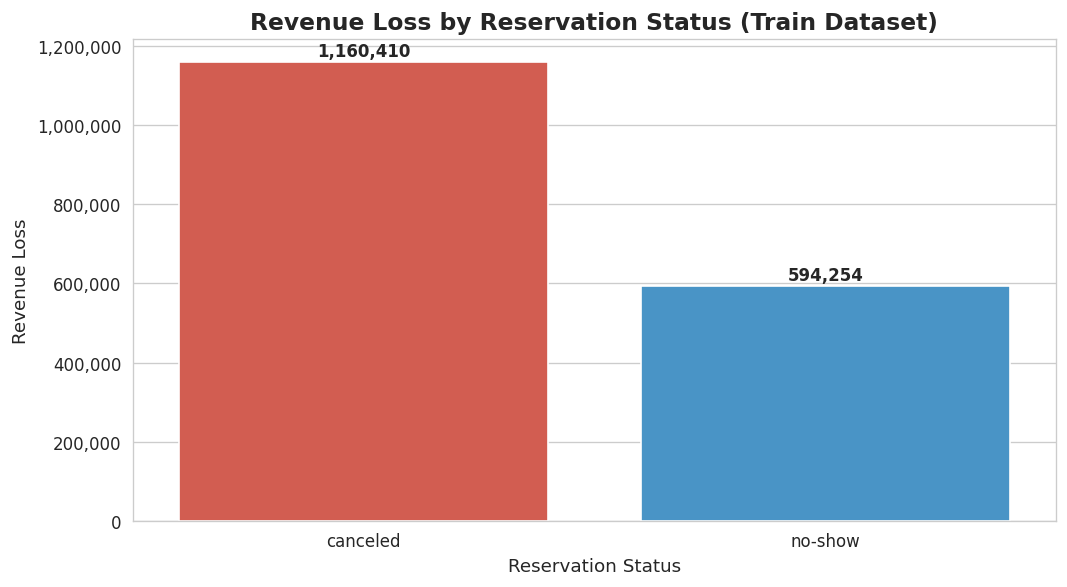

In [344]:
import matplotlib.ticker as mtick

# Filter out checkout (no revenue loss)
train_filtered = train[train['reservation_status'] != 'checkout']

# Group data
train_status_plot = train_filtered.groupby('reservation_status', as_index=False)['Revenue_Loss'].sum()

# Order only relevant categories
status_order = ['canceled', 'no-show']
train_status_plot['reservation_status'] = pd.Categorical(
    train_status_plot['reservation_status'],
    categories=status_order,
    ordered=True
)
train_status_plot = train_status_plot.sort_values('reservation_status')

# Plot
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=train_status_plot,
    x='reservation_status',
    y='Revenue_Loss',
    hue='reservation_status',
    palette=['#e74c3c', '#3498db'],
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Reservation Status (Train Dataset)', fontweight='bold')
plt.xlabel('Reservation Status')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add labels
for p in ax.patches:
    height = p.get_height()
    y_pos = height + 5000 if height > 0 else 5000
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, y_pos),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

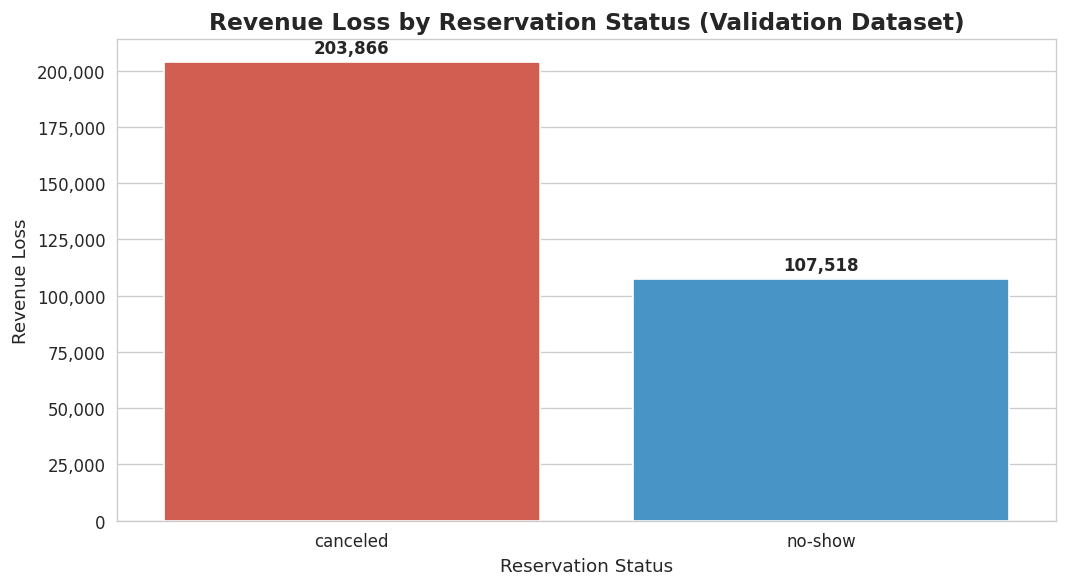

In [345]:
# 2. Revenue Loss by Reservation Status - Validation

# Filter out checkout (no revenue loss)
validation_filtered = validation[validation['reservation_status'] != 'checkout']

# Group data
validation_status_plot = validation_filtered.groupby('reservation_status', as_index=False)['Revenue_Loss'].sum()

# Order only relevant categories
status_order = ['canceled', 'no-show']
validation_status_plot['reservation_status'] = pd.Categorical(
    validation_status_plot['reservation_status'],
    categories=status_order,
    ordered=True
)
validation_status_plot = validation_status_plot.sort_values('reservation_status')

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=validation_status_plot,
    x='reservation_status',
    y='Revenue_Loss',
    hue='reservation_status',
    palette=['#e74c3c', '#3498db'],
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Reservation Status (Validation Dataset)', fontweight='bold')
plt.xlabel('Reservation Status')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    y_pos = height + 2000 if height > 0 else 2000
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, y_pos),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

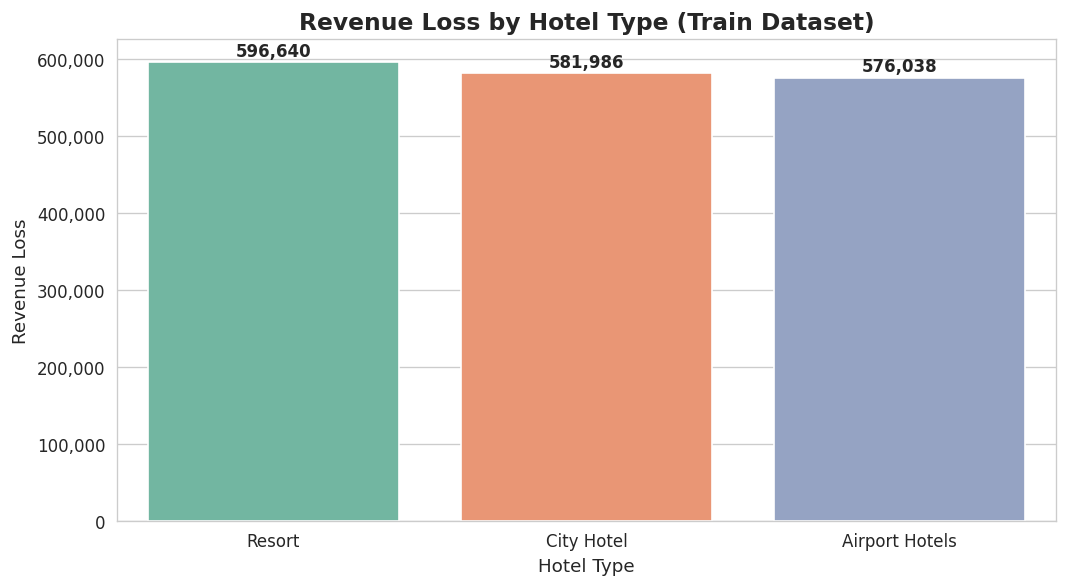

In [346]:
# 3. Revenue Loss by Hotel Type - Train

train_hotel_plot = train.groupby('hotel_type', as_index=False)['Revenue_Loss'].sum()
train_hotel_plot = train_hotel_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=train_hotel_plot,
    x='hotel_type',
    y='Revenue_Loss',
    hue='hotel_type',
    palette='Set2',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Hotel Type (Train Dataset)', fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 3000),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

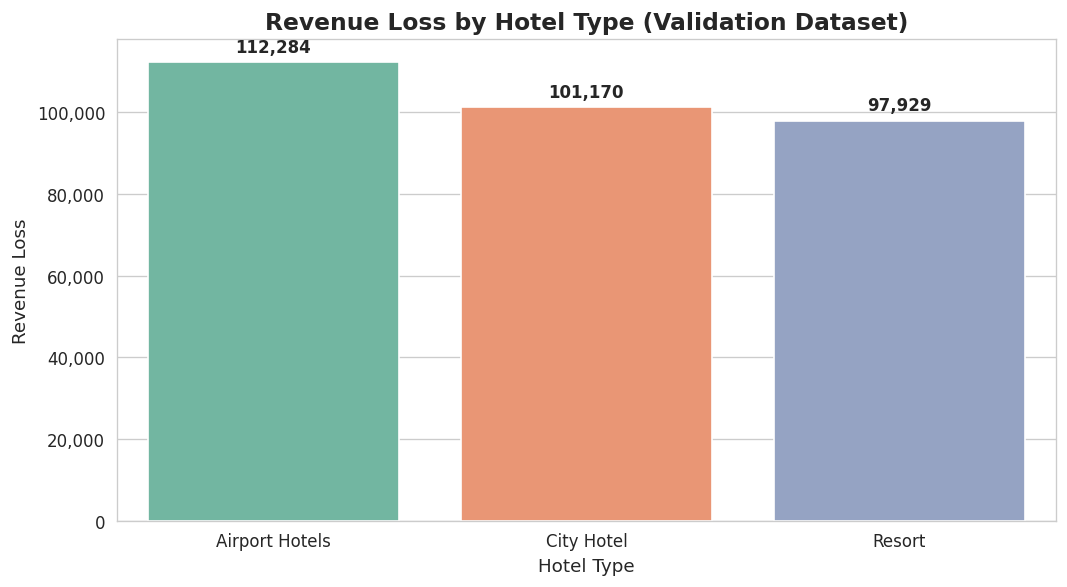

In [347]:
# 4. Revenue Loss by Hotel Type - Validation

validation_hotel_plot = validation.groupby('hotel_type', as_index=False)['Revenue_Loss'].sum()
validation_hotel_plot = validation_hotel_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=validation_hotel_plot,
    x='hotel_type',
    y='Revenue_Loss',
    hue='hotel_type',
    palette='Set2',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Hotel Type (Validation Dataset)', fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 1500),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

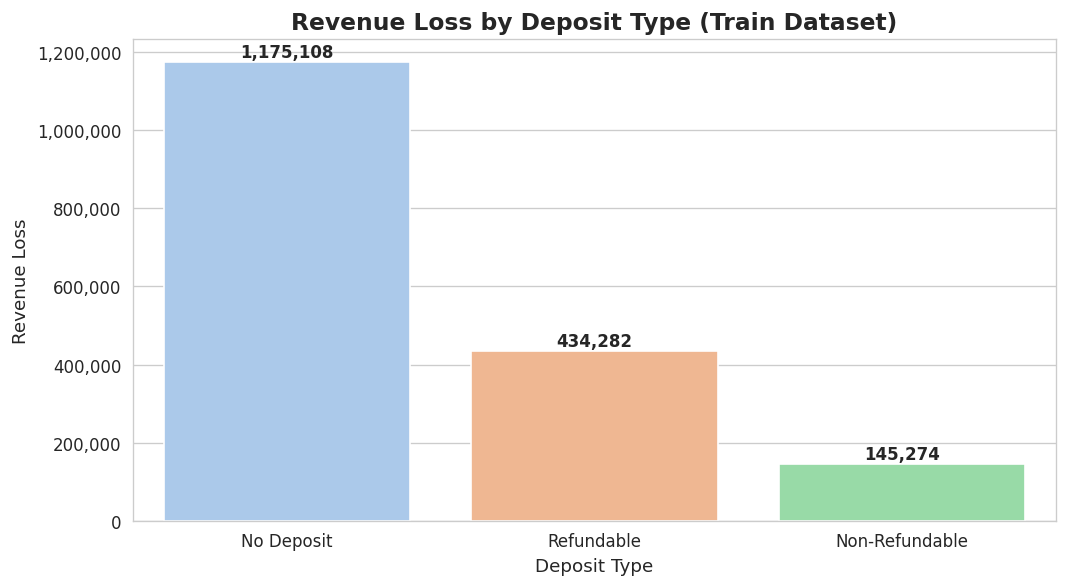

In [348]:
# 5. Revenue Loss by Deposit Type - Train

train_deposit_plot = train.groupby('deposit_type', as_index=False)['Revenue_Loss'].sum()
train_deposit_plot = train_deposit_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=train_deposit_plot,
    x='deposit_type',
    y='Revenue_Loss',
    hue='deposit_type',
    palette='pastel',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Deposit Type (Train Dataset)', fontweight='bold')
plt.xlabel('Deposit Type')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 3000),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

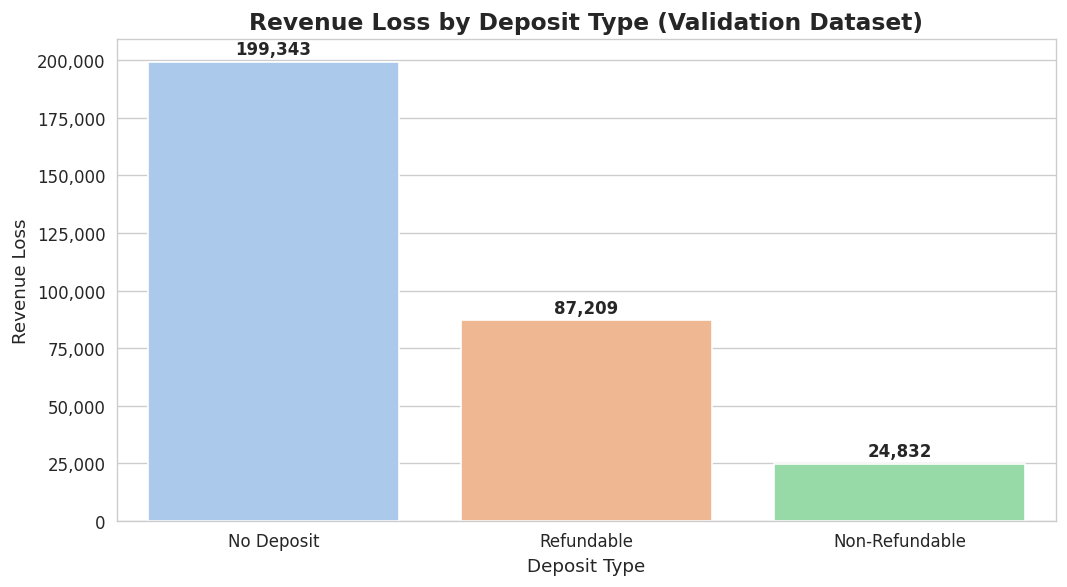

In [349]:
# 6. Revenue Loss by Deposit Type - Validation

validation_deposit_plot = validation.groupby('deposit_type', as_index=False)['Revenue_Loss'].sum()
validation_deposit_plot = validation_deposit_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=validation_deposit_plot,
    x='deposit_type',
    y='Revenue_Loss',
    hue='deposit_type',
    palette='pastel',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Deposit Type (Validation Dataset)', fontweight='bold')
plt.xlabel('Deposit Type')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 1500),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

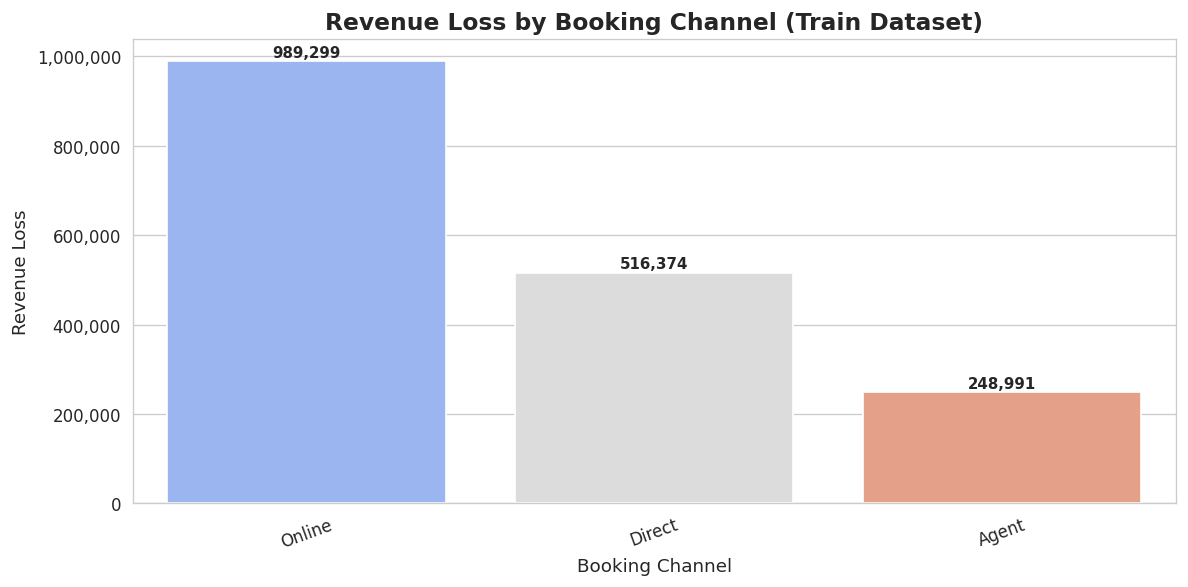

In [350]:
# 7. Revenue Loss by Booking Channel - Train

train_channel_plot = train.groupby('booking_channel', as_index=False)['Revenue_Loss'].sum()
train_channel_plot = train_channel_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=train_channel_plot,
    x='booking_channel',
    y='Revenue_Loss',
    hue='booking_channel',
    palette='coolwarm',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Booking Channel (Train Dataset)', fontweight='bold')
plt.xlabel('Booking Channel')
plt.ylabel('Revenue Loss')
plt.xticks(rotation=20)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 3000),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

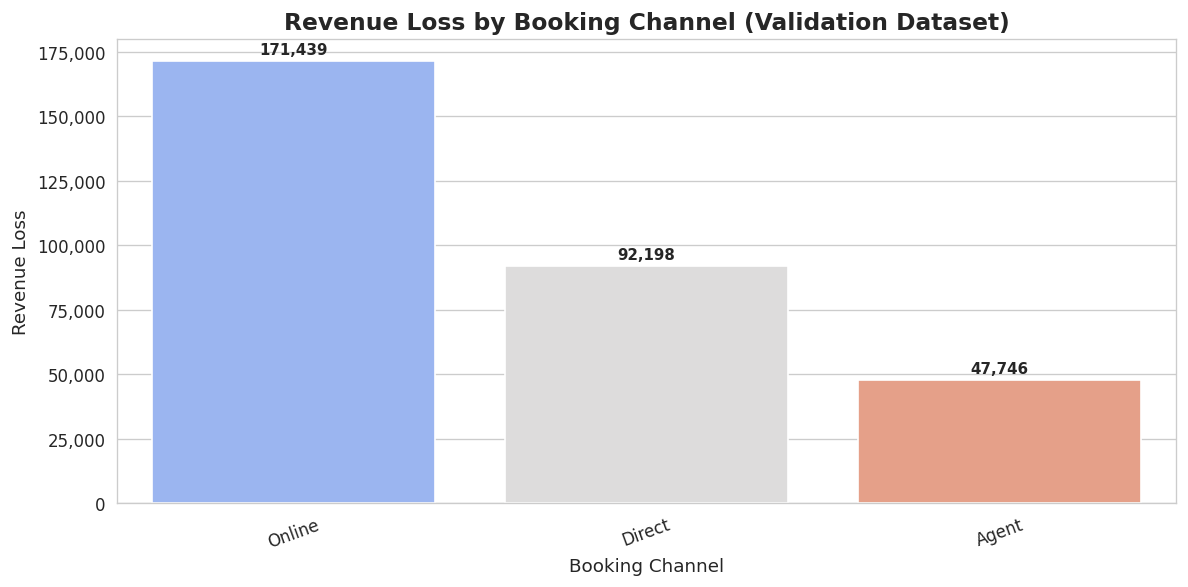

In [351]:
# 8. Revenue Loss by Booking Channel - Validation

validation_channel_plot = validation.groupby('booking_channel', as_index=False)['Revenue_Loss'].sum()
validation_channel_plot = validation_channel_plot.sort_values('Revenue_Loss', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=validation_channel_plot,
    x='booking_channel',
    y='Revenue_Loss',
    hue='booking_channel',
    palette='coolwarm',
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Booking Channel (Validation Dataset)', fontweight='bold')
plt.xlabel('Booking Channel')
plt.ylabel('Revenue Loss')
plt.xticks(rotation=20)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 1500),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

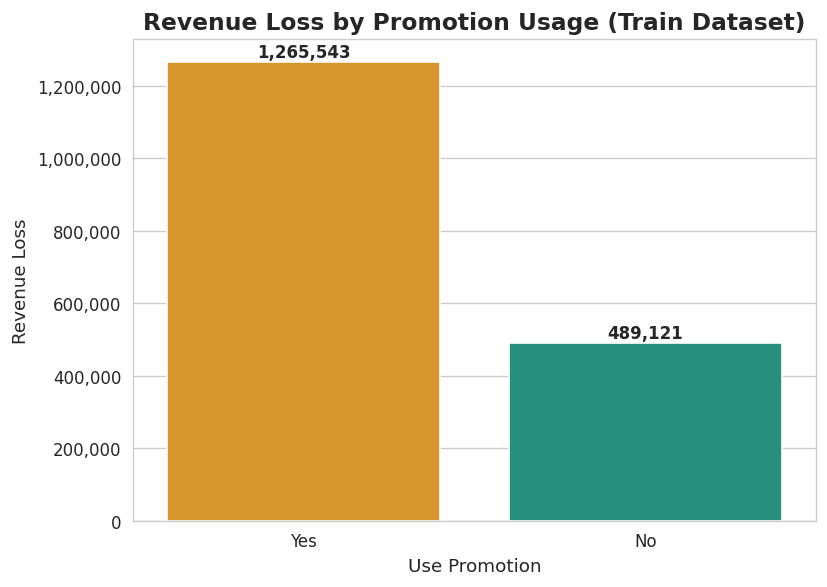

In [352]:
# 9. Revenue Loss by Promotion Usage - Train

train_promo_plot = train.groupby('use_promotion', as_index=False)['Revenue_Loss'].sum()

promo_order = ['Yes', 'No']
train_promo_plot['use_promotion'] = pd.Categorical(
    train_promo_plot['use_promotion'],
    categories=promo_order,
    ordered=True
)
train_promo_plot = train_promo_plot.sort_values('use_promotion')

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=train_promo_plot,
    x='use_promotion',
    y='Revenue_Loss',
    hue='use_promotion',
    palette=['#f39c12', '#16a085'],
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Promotion Usage (Train Dataset)', fontweight='bold')
plt.xlabel('Use Promotion')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 3000),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

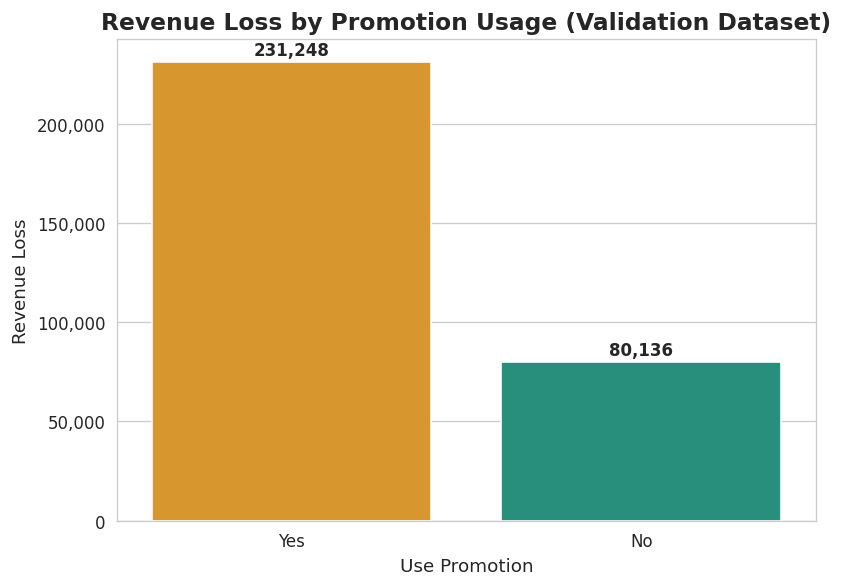

In [353]:
# 10. Revenue Loss by Promotion Usage - Validation

validation_promo_plot = validation.groupby('use_promotion', as_index=False)['Revenue_Loss'].sum()

validation_promo_plot['use_promotion'] = pd.Categorical(
    validation_promo_plot['use_promotion'],
    categories=promo_order,
    ordered=True
)
validation_promo_plot = validation_promo_plot.sort_values('use_promotion')

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=validation_promo_plot,
    x='use_promotion',
    y='Revenue_Loss',
    hue='use_promotion',
    palette=['#f39c12', '#16a085'],
    dodge=False,
    errorbar=None,
    legend=False
)

plt.title('Revenue Loss by Promotion Usage (Validation Dataset)', fontweight='bold')
plt.xlabel('Use Promotion')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 1500),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

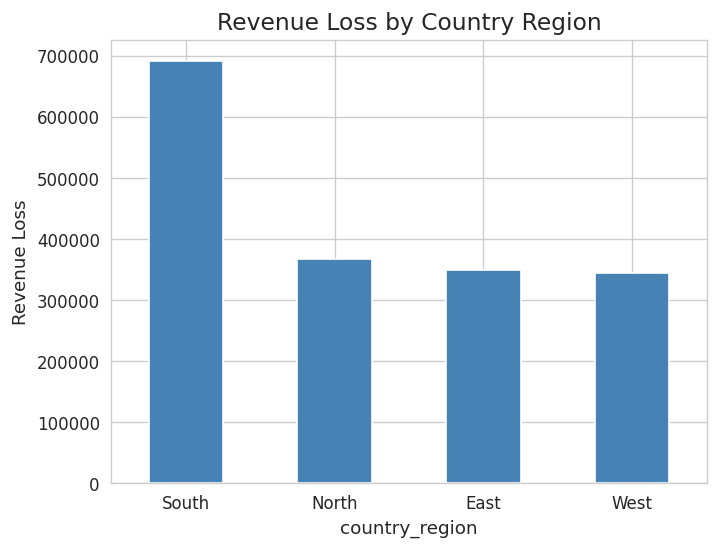

In [354]:
# 11. Country Region vs Revenue Loss
region_loss = train.groupby('country_region')['Revenue_Loss'].sum().sort_values(ascending=False)
region_loss.plot(kind='bar', color='steelblue')
plt.title('Revenue Loss by Country Region')
plt.ylabel('Revenue Loss')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_7813/3103487473.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_loss = train.groupby('age_group')['Revenue_Loss'].sum().sort_values(ascending=False)


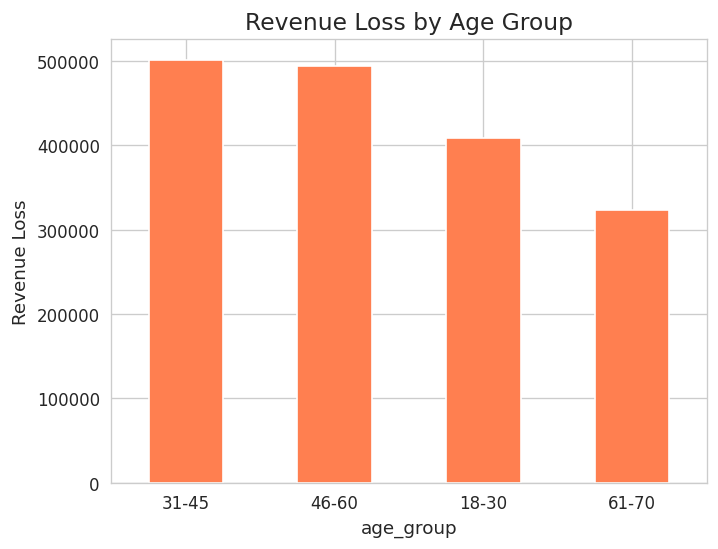

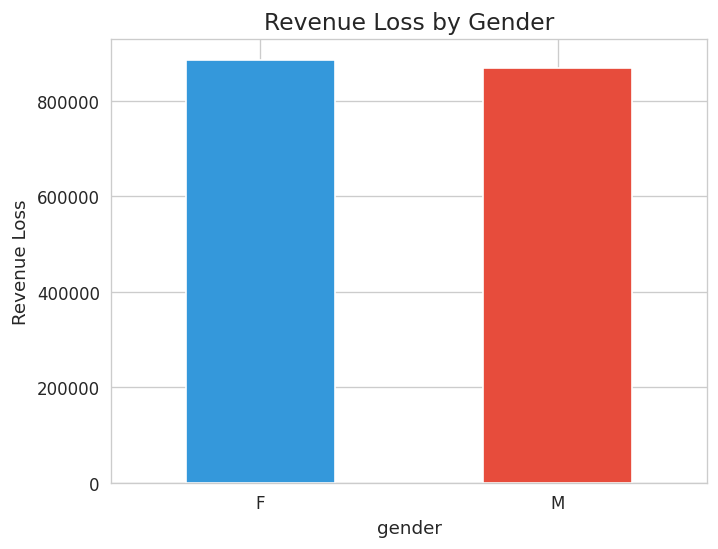

In [355]:
# 12. Revenue loss by age group
age_loss = train.groupby('age_group')['Revenue_Loss'].sum().sort_values(ascending=False)
age_loss.plot(kind='bar', color='coral')
plt.title('Revenue Loss by Age Group')
plt.ylabel('Revenue Loss')
plt.xticks(rotation=0)
plt.show()

# 13. Revenue loss by gender
gender_loss = train.groupby('gender')['Revenue_Loss'].sum()
gender_loss.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Revenue Loss by Gender')
plt.ylabel('Revenue Loss')
plt.xticks(rotation=0)
plt.show()

## **Feature Engineering**

In [356]:
#Group 1- dropping reservation id column
for dataset_df in [train, validation, test]:
    dataset_df.drop(columns=['reservation-id'], inplace=True)
    print(f'Columns after drop for a dataset: {dataset_df.shape[1]}')

Columns after drop for a dataset: 29
Columns after drop for a dataset: 27
Columns after drop for a dataset: 25


In [359]:
#Group 2- Date-Based Features
for dataset_df in [train, validation, test]:
    # Parse dates
    dataset_df['expected_checkin']  = pd.to_datetime(dataset_df['expected_checkin'])
    dataset_df['expected_checkout'] = pd.to_datetime(dataset_df['expected_checkout'])
    dataset_df['booking_date']      = pd.to_datetime(dataset_df['booking_date'])

    # Length of stay (nights)
    dataset_df['Length_of_Stay'] = (dataset_df['expected_checkout'] - dataset_df['expected_checkin']).dt.days

    # Lead time: days between booking and check-in
    dataset_df['Lead_Time'] = (dataset_df['expected_checkin'] - dataset_df['booking_date']).dt.days

    # Checkin month and day-of-week
    dataset_df['Checkin_Month']     = dataset_df['expected_checkin'].dt.month
    dataset_df['Checkin_DayOfWeek'] = dataset_df['expected_checkin'].dt.dayofweek  # 0=Monday, 6=Sunday

    # Weekend check-in flag
    dataset_df['Is_Weekend_Checkin'] = dataset_df['Checkin_DayOfWeek'].isin([5, 6]).astype(int)

    # Season of check-in
    def get_season(month):
        if month in [12, 1, 2]:  return 'Winter'
        elif month in [3, 4, 5]: return 'Spring'
        elif month in [6, 7, 8]: return 'Summer'
        else:                    return 'Fall'

    dataset_df['Checkin_Season'] = dataset_df['Checkin_Month'].apply(get_season)

# Display head for one of the dataframes to confirm
print("Train DataFrame with new features:")
print(train[['expected_checkin','expected_checkout','booking_date',
        'Length_of_Stay','Lead_Time','Checkin_Month',
        'Checkin_DayOfWeek','Is_Weekend_Checkin','Checkin_Season']].head())

Train DataFrame with new features:
  expected_checkin expected_checkout booking_date  Length_of_Stay  Lead_Time  \
0       2015-07-01        2015-07-02   2015-05-21               1         41   
1       2015-07-01        2015-07-02   2015-05-26               1         36   
2       2015-07-02        2015-07-06   2015-06-29               4          3   
3       2015-07-02        2015-07-03   2015-06-20               1         12   
4       2015-07-03        2015-07-04   2015-06-20               1         13   

   Checkin_Month  Checkin_DayOfWeek  Is_Weekend_Checkin Checkin_Season  
0              7                  2                   0         Summer  
1              7                  2                   0         Summer  
2              7                  3                   0         Summer  
3              7                  3                   0         Summer  
4              7                  4                   0         Summer  


/tmp/ipykernel_7813/1761619070.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=train_season_plot, x='Checkin_Season', y='Revenue_Loss', palette='coolwarm')


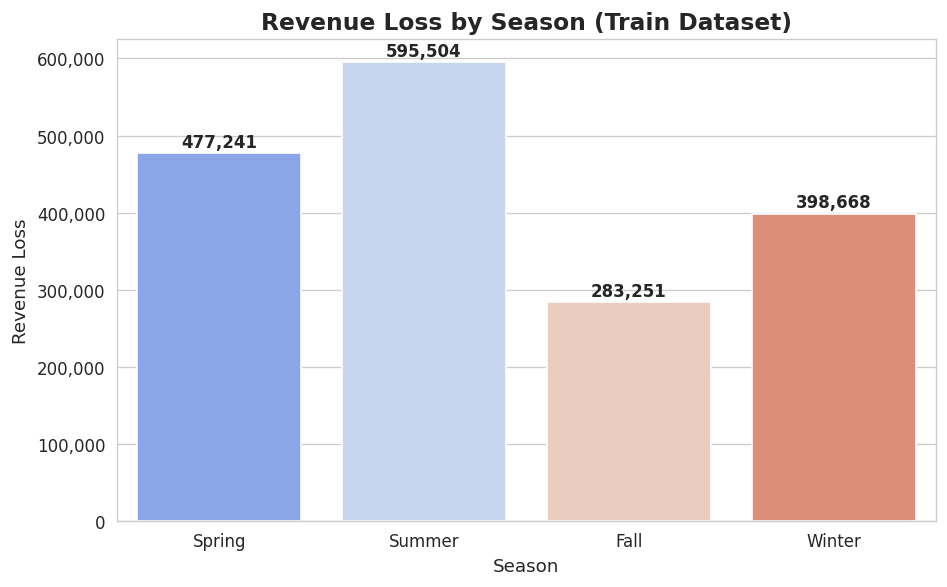

/tmp/ipykernel_7813/1761619070.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=train_month_plot, x='Checkin_Month', y='Revenue_Loss', palette='viridis')


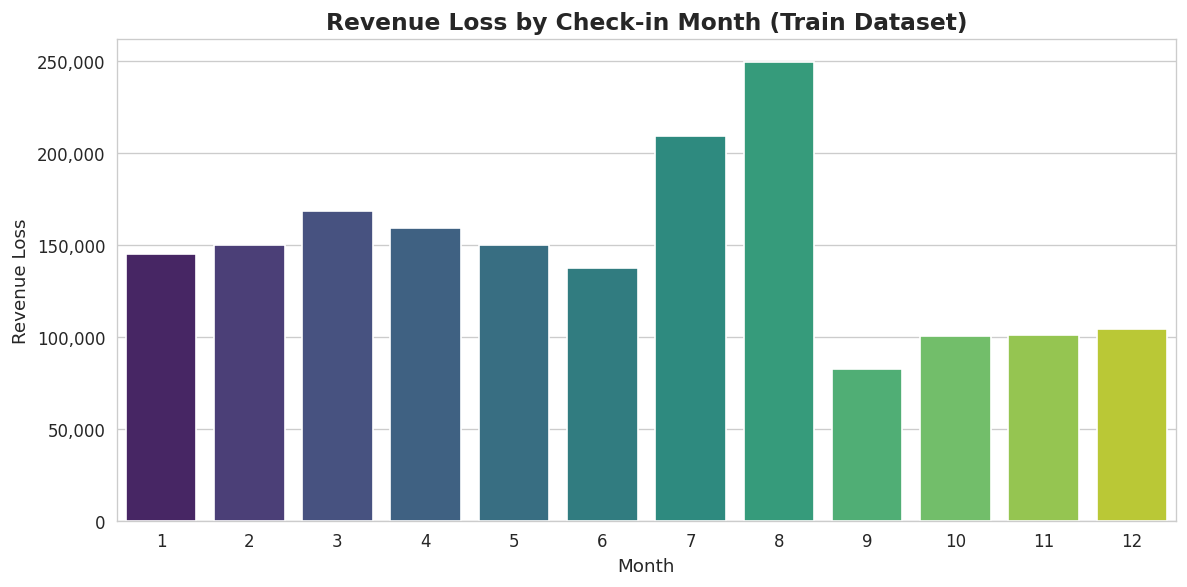

In [360]:
# Revenue Loss by Check-in Season
train_season_plot = train.groupby('Checkin_Season', as_index=False)['Revenue_Loss'].sum()
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
train_season_plot['Checkin_Season'] = pd.Categorical(train_season_plot['Checkin_Season'],
                                                      categories=season_order, ordered=True)
train_season_plot = train_season_plot.sort_values('Checkin_Season')

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=train_season_plot, x='Checkin_Season', y='Revenue_Loss', palette='coolwarm')
plt.title('Revenue Loss by Season (Train Dataset)', fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width()/2, p.get_height() + 3000),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Revenue Loss by Month
train_month_plot = train.groupby('Checkin_Month', as_index=False)['Revenue_Loss'].sum()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=train_month_plot, x='Checkin_Month', y='Revenue_Loss', palette='viridis')
plt.title('Revenue Loss by Check-in Month (Train Dataset)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

Lead Time vs Reservation Status

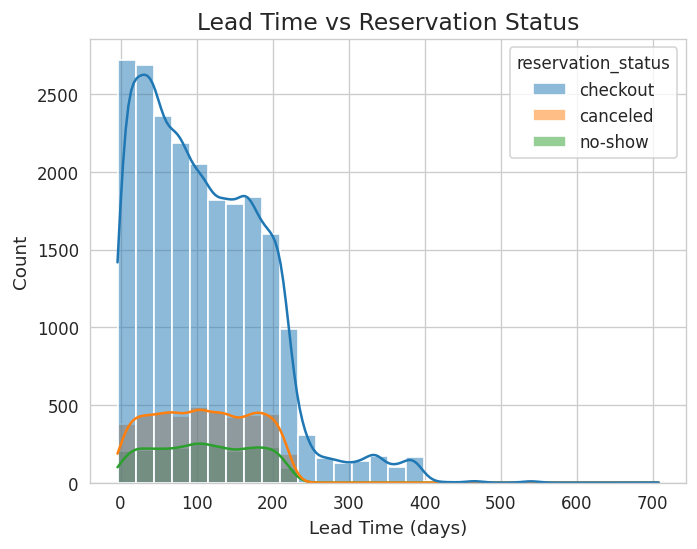

In [362]:
sns.histplot(data=train, x='Lead_Time', hue='reservation_status', bins=30, kde=True)
plt.title("Lead Time vs Reservation Status")
plt.xlabel("Lead Time (days)")
plt.show()

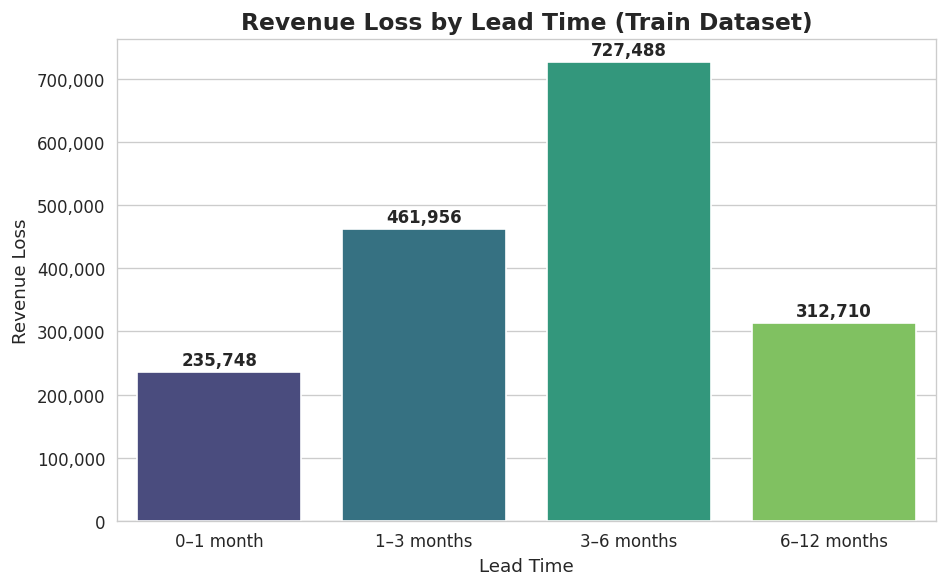

In [364]:
import matplotlib.ticker as mtick

# 14. Revenue Loss by Lead time - Train

# Filter out successful bookings (important)
train_filtered = train[train['reservation_status'] != 'checkout'].copy()

# Create lead time groups (months-style bins)
bins = [0, 30, 90, 180, 365]
labels = ['0–1 month', '1–3 months', '3–6 months', '6–12 months']

train_filtered['lead_time_group'] = pd.cut(
    train_filtered['Lead_Time'],
    bins=bins,
    labels=labels,
    right=False
)

# Group revenue loss
train_lead_plot = train_filtered.groupby('lead_time_group', as_index=False, observed=False)['Revenue_Loss'].sum()

# Sort properly
train_lead_plot['lead_time_group'] = pd.Categorical(
    train_lead_plot['lead_time_group'],
    categories=labels,
    ordered=True
)
train_lead_plot = train_lead_plot.sort_values('lead_time_group')

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=train_lead_plot,
    x='lead_time_group',
    y='Revenue_Loss',
    hue='lead_time_group',
    palette='viridis',
    legend=False
)

plt.title('Revenue Loss by Lead Time (Train Dataset)', fontweight='bold')
plt.xlabel('Lead Time')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 5000),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

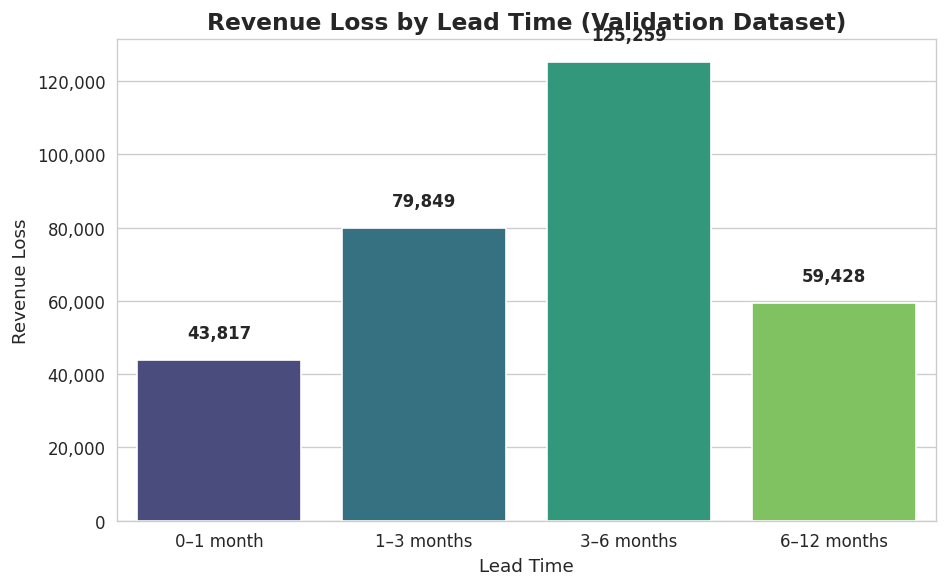

In [367]:
import matplotlib.ticker as mtick

# 15. Revenue Loss by Lead time - Validation

# Filter out successful bookings
validation_filtered = validation[validation['reservation_status'] != 'checkout'].copy()

# Create lead time groups
bins = [0, 30, 90, 180, 365]
labels = ['0–1 month', '1–3 months', '3–6 months', '6–12 months']

validation_filtered['lead_time_group'] = pd.cut(
    validation_filtered['Lead_Time'],
    bins=bins,
    labels=labels,
    right=False
)

# Group revenue loss
validation_lead_plot = validation_filtered.groupby('lead_time_group', as_index=False, observed=False)['Revenue_Loss'].sum()

# Sort properly
validation_lead_plot['lead_time_group'] = pd.Categorical(
    validation_lead_plot['lead_time_group'],
    categories=labels,
    ordered=True
)
validation_lead_plot = validation_lead_plot.sort_values('lead_time_group')

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=validation_lead_plot,
    x='lead_time_group',
    y='Revenue_Loss',
    hue='lead_time_group',
    palette='viridis',
    legend=False
)

plt.title('Revenue Loss by Lead Time (Validation Dataset)', fontweight='bold')
plt.xlabel('Lead Time')
plt.ylabel('Revenue Loss')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2, height + 5000),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [368]:
# Negative lead times treated as same-day bookings (data entry assumption)
train['Lead_Time'] = train['Lead_Time'].clip(lower=0)
validation['Lead_Time'] = validation['Lead_Time'].clip(lower=0)
test['Lead_Time'] = test['Lead_Time'].clip(lower=0)

In [369]:
# Filter only cancellations
canceled_only = train[train['reservation_status'] == 'canceled'].copy()

# Bin by how close to check-in the cancellation happened
bins = [0, 7, 30, 90, 180, 365]
labels = ['0–7 days', '8–30 days', '31–90 days', '91–180 days', '181–365 days']

canceled_only['cancellation_timing'] = pd.cut(
    canceled_only['Lead_Time'],
    bins=bins,
    labels=labels,
    right=False
)

timing_counts = canceled_only['cancellation_timing'].value_counts().sort_index()
timing_revenue = canceled_only.groupby('cancellation_timing')['Revenue_Loss'].sum().sort_index()

print("Number of Cancellations by Timing:")
print(timing_counts)
print("\nRevenue Loss by Cancellation Timing:")
print(timing_revenue)

Number of Cancellations by Timing:
cancellation_timing
0–7 days         159
8–30 days        417
31–90 days      1107
91–180 days     1709
181–365 days     742
Name: count, dtype: int64

Revenue Loss by Cancellation Timing:
cancellation_timing
0–7 days         45540.55
8–30 days       120786.00
31–90 days      309028.00
91–180 days     479783.30
181–365 days    205272.60
Name: Revenue_Loss, dtype: float64


/tmp/ipykernel_7813/1472119002.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  timing_revenue = canceled_only.groupby('cancellation_timing')['Revenue_Loss'].sum().sort_index()


Analysing the timing of cancellations relative to check-in date to identify late cancellations, which are more damaging as they leave insufficient time for the hotel to re-sell the room.

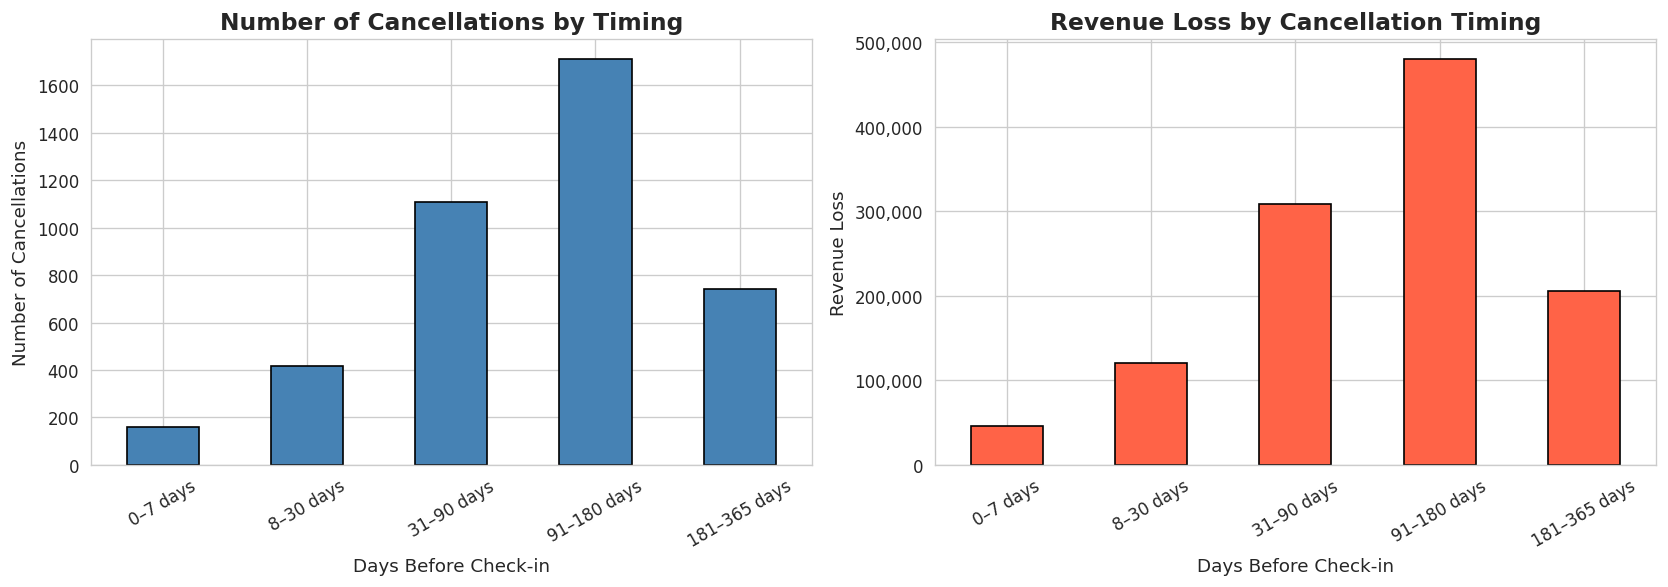

In [371]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
timing_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Number of Cancellations by Timing', fontweight='bold')
axes[0].set_xlabel('Days Before Check-in')
axes[0].set_ylabel('Number of Cancellations')
axes[0].tick_params(axis='x', rotation=30)

# Revenue loss plot
timing_revenue.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Revenue Loss by Cancellation Timing', fontweight='bold')
axes[1].set_xlabel('Days Before Check-in')
axes[1].set_ylabel('Revenue Loss')
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [372]:
#Group 3- Guest Count Features
for dataset_df in [train, validation, test]:
    # Total guests per booking
    dataset_df['Total_Guests'] = dataset_df['adults'] + dataset_df['children'] + dataset_df['babies']

    # Family flag (has children or babies)
    dataset_df['Is_Family'] = ((dataset_df['children'] > 0) | (dataset_df['babies'] > 0)).astype(int)

    # Guest type category
    def guest_type(row):
        if row['children'] > 0 or row['babies'] > 0:
            return 'Family'
        elif row['adults'] == 1:
            return 'Solo'
        else:
            return 'Group'

    dataset_df['Guest_Type'] = dataset_df.apply(guest_type, axis=1)

# Display head for one of the dataframes to confirm
print("Train DataFrame with new guest features:")
print(train[['adults','children','babies','Total_Guests','Is_Family','Guest_Type']].head(10))

Train DataFrame with new guest features:
   adults  children  babies  Total_Guests  Is_Family Guest_Type
0     2.0         2       0           4.0          1     Family
1     3.0         3       0           6.0          1     Family
2     3.0         3       0           6.0          1     Family
3     4.0         3       0           7.0          1     Family
4     1.0         1       0           2.0          1     Family
5     4.5         2       1           7.5          1     Family
6     2.0         1       0           3.0          1     Family
7     2.0         1       0           3.0          1     Family
8     3.0         2       0           5.0          1     Family
9     2.0         3       0           5.0          1     Family


In [373]:
# Group 4- Ordinal Encoding for Income and Education
for dataset_df in [train, validation, test]:
    # Income: low → high
    income_order = {'<25K': 0, '25K --50K': 1, '50K -- 100K': 2, '>100K': 3}
    dataset_df['income_enc'] = dataset_df['income'].map(income_order)

    # Education: lowest → highest
    edu_order = {'Mid-School': 0, 'High-School': 1, 'College': 2, 'Grad': 3}
    dataset_df['education_enc'] = dataset_df['educational_level'].map(edu_order)

# Display head for one of the dataframes to confirm
print("Train DataFrame with new encoded features:")
print(train[['income','income_enc','educational_level','education_enc']].drop_duplicates().sort_values('income_enc'))

Train DataFrame with new encoded features:
      income  income_enc educational_level  education_enc
0       <25K         0.0              Grad              3
6       <25K         0.0       High-School              1
18      <25K         0.0           College              2
17      <25K         0.0        Mid-School              0
7      >100K         3.0        Mid-School              0
3      >100K         3.0           College              2
15     >100K         3.0              Grad              3
21     >100K         3.0       High-School              1
1   50K-100K         NaN        Mid-School              0
4    25K-50K         NaN       High-School              1
9   50K-100K         NaN              Grad              3
11  50K-100K         NaN           College              2
12   25K-50K         NaN           College              2
16   25K-50K         NaN              Grad              3
23   25K-50K         NaN        Mid-School              0
37  50K-100K         NaN     

Original vs After Feature Engineering

In [376]:
# Before vs After Feature Engineering Comparison

print('=== BEFORE FEATURE ENGINEERING ===')
print('Original columns in raw dataset:')
original_cols = [
    'age', 'adults', 'children', 'babies',
    'room_rate', 'discount_rate', 'booking_date',
    'expected_checkin', 'expected_checkout',
    'reservation_status'
]
print(original_cols)
print('Total original columns:', len(original_cols))

print('\n=== AFTER FEATURE ENGINEERING ===')
print('New columns added:')
new_cols = [col for col in train.columns if col not in [
    'gender', 'age', 'ethnicity', 'educational_level', 'income',
    'country_region', 'hotel_type', 'expected_checkin', 'expected_checkout',
    'booking_date', 'adults', 'children', 'babies', 'meal_type',
    'visted_previously', 'previous_cancellations', 'deposit_type',
    'booking_channel', 'required_car_parking', 'reservation_status',
    'use_promotion', 'discount_rate', 'room_rate', 'is_canceled',
    'Gross_Revenue', 'Net_Revenue', 'Revenue_Loss',
    'lead_time_group', 'length_of_stay', 'Length_of_Stay'
]]
print(new_cols)
print('Total new columns added:', len(new_cols))

print('\n=== FULL DATASET SHAPE COMPARISON ===')
print(f'Original dataset : 27499 rows x 24 columns')
print(f'After engineering: {train.shape[0]} rows x {train.shape[1]} columns')
print(f'New features added: {train.shape[1] - 24}')

print('\n=== SAMPLE OF NEW FEATURES (first 3 rows) ===')
new_feature_sample = [
    'Lead_Time', 'Length_of_Stay', 'Checkin_Month',
    'Checkin_DayOfWeek', 'Is_Weekend_Checkin',
    'Total_Guests', 'Is_Family', 'Guest_Type',
    'income_enc', 'education_enc', 'Capacity_Exceeded'
]
# Only show columns that exist
existing = [c for c in new_feature_sample if c in train.columns]
print(train[existing].head(3))

=== BEFORE FEATURE ENGINEERING ===
Original columns in raw dataset:
['age', 'adults', 'children', 'babies', 'room_rate', 'discount_rate', 'booking_date', 'expected_checkin', 'expected_checkout', 'reservation_status']
Total original columns: 10

=== AFTER FEATURE ENGINEERING ===
New columns added:
['age_group', 'is_lost_booking', 'Lead_Time', 'Checkin_Month', 'Checkin_DayOfWeek', 'Is_Weekend_Checkin', 'Checkin_Season', 'Total_Guests', 'Is_Family', 'Guest_Type', 'income_enc', 'education_enc']
Total new columns added: 12

=== FULL DATASET SHAPE COMPARISON ===
Original dataset : 27499 rows x 24 columns
After engineering: 27499 rows x 39 columns
New features added: 15

=== SAMPLE OF NEW FEATURES (first 3 rows) ===
   Lead_Time  Length_of_Stay  Checkin_Month  Checkin_DayOfWeek  \
0         41               1              7                  2   
1         36               1              7                  2   
2          3               4              7                  3   

   Is_Weekend_Ch

## **Preprocessing**

In [377]:
# Documenting that children values are ordinal codes (1=low, 2=medium, 3=high)
# not actual child counts — treat as ordinal feature in modelling
for df in [train, validation, test]:
    df['children'] = df['children'].astype(int)  # keeping as ordinal numeric

print('Children treated as ordinal code (1/2/3) not actual count')

Children treated as ordinal code (1/2/3) not actual count


In [245]:
#Group by promotion and discount
train_promo_discount_summary = train.groupby(['use_promotion', 'discount_rate']).agg(
    Total_Bookings=('gender', 'count'), # Changed from 'reservation-id' to 'gender'
    Total_Revenue_Loss=('Revenue_Loss', 'sum'),
    Avg_Revenue_Loss=('Revenue_Loss', 'mean')
).reset_index()

print("\nTrain - Revenue Loss by Promotion Usage and Discount Rate:")
print(train_promo_discount_summary.sort_values(by='Total_Revenue_Loss', ascending=False).to_string())


Train - Revenue Loss by Promotion Usage and Discount Rate:
  use_promotion  discount_rate  Total_Bookings  Total_Revenue_Loss  Avg_Revenue_Loss
0            No              0            6829            489121.0         71.624103
2           Yes             10            5469            381457.8         69.749095
1           Yes              5            4159            288309.8         69.321904
4           Yes             20            4162            238105.6         57.209419
5           Yes             25            2721            145438.5         53.450386
3           Yes             15            1443             83357.8         57.767013
6           Yes             30            1343             66496.5         49.513403
7           Yes             40            1373             62377.2         45.431318


In [246]:
print("Train Lead_Time min after clipping:", train['Lead_Time'].min())

Train Lead_Time min after clipping: 0


In [247]:
# Cap 'Lead_Time' at 365 days for all datasets
for df in [train, validation, test]:
    # Cap 'lead_time' (created during EDA)
    if 'lead_time' in df.columns:
        df['lead_time'] = df['lead_time'].clip(upper=365)
    # Cap 'Lead_Time' (created during Feature Engineering)
    if 'Lead_Time' in df.columns:
        df['Lead_Time'] = df['Lead_Time'].clip(upper=365)

print("Train Lead_Time max after capping:", train['Lead_Time'].max())

Train Lead_Time max after capping: 365


In [248]:
#Capacity Exceeded Feature
#Defining a reasonable room capacity threshold. Assuming 5 guests as a standard maximum for a single room booking.
ROOM_CAPACITY_THRESHOLD = 5

for dataset_df in [train, validation, test]:
    # 'Total_Guests' was already created in 'Group 3 - Guest Count Features'
    dataset_df['Capacity_Exceeded'] = (dataset_df['Total_Guests'] > ROOM_CAPACITY_THRESHOLD).astype(int)

# Display head for one of the dataframes to confirm
print("Train DataFrame with new 'Capacity_Exceeded' feature:")
print(train[['adults', 'children', 'babies', 'Total_Guests', 'Capacity_Exceeded']].head(10))

Train DataFrame with new 'Capacity_Exceeded' feature:
   adults  children  babies  Total_Guests  Capacity_Exceeded
0     2.0         2       0           4.0                  0
1     3.0         3       0           6.0                  1
2     3.0         3       0           6.0                  1
3     4.0         3       0           7.0                  1
4     1.0         1       0           2.0                  0
5     4.5         2       1           7.5                  1
6     2.0         1       0           3.0                  0
7     2.0         1       0           3.0                  0
8     3.0         2       0           5.0                  0
9     2.0         3       0           5.0                  0


## **Exporting Cleaned datasets**

Save the cleaned data sets

In [249]:
train.to_csv("/content/drive/MyDrive/DSPL/GCW/Data/Processed/train_cleaned.csv", index=False)
validation.to_csv("/content/drive/MyDrive/DSPL/GCW/Data/Processed/validation_cleaned.csv", index=False)
test.to_csv("/content/drive/MyDrive/DSPL/GCW/Data/Processed/test_cleaned.csv", index=False)